## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "mass_smaller_30"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [5]:
override = True
use_preds = False
save = True
show = True

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


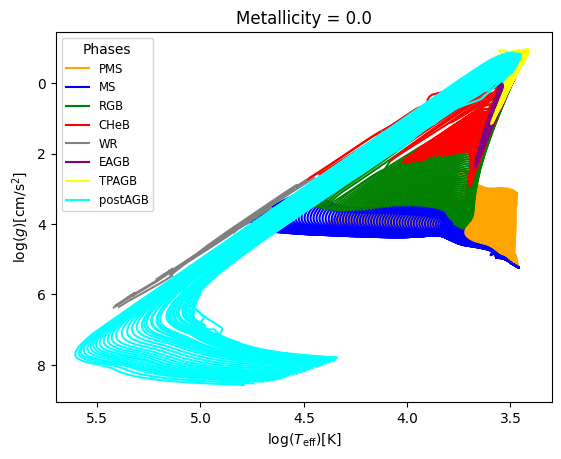

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

In [7]:
print_uniques("star_mass", iso_df)
# print_uniques_count("star_mass", iso_df)

star_mass : 1467117 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
630600,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
630601,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
630602,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
630603,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


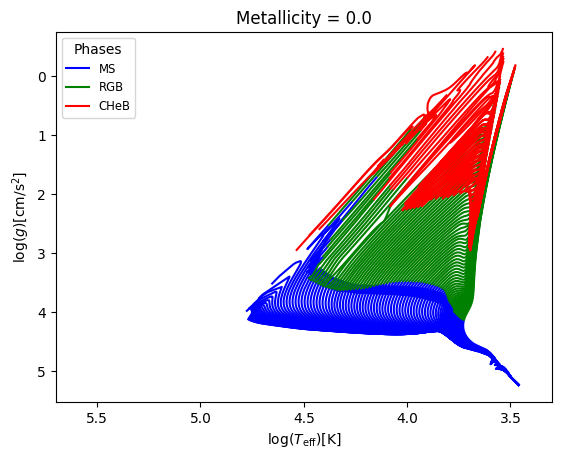

In [8]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [9]:
print_uniques("star_mass", phase_filtered_iso_df)
# print_uniques_count("star_mass", phase_filtered_iso_df)

star_mass : 630605 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
573998,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
573999,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
574000,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
574001,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


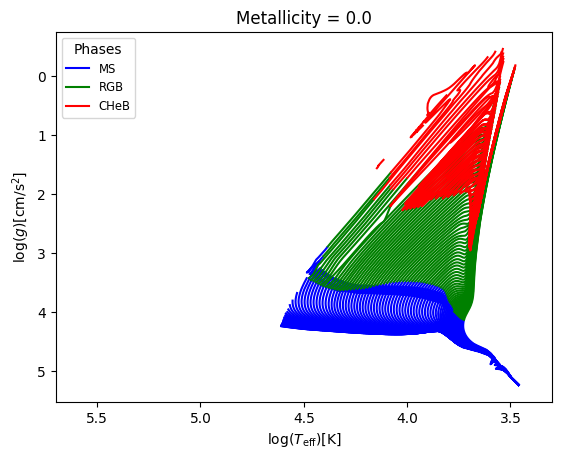

In [10]:
phase_mass_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], "star_mass" : ("<", 30)})
display(phase_mass_filtered_iso_df)
data_visualiser_phase_age_filtered = Data_visualiser(phase_mass_filtered_iso_df, physical_model)
data_visualiser_phase_age_filtered.plot_Kiel([], [0.0])

In [11]:
print_all_uniques(phase_mass_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.2913, Median : 8.3

log_Teff  : Range : 3.34 - 5.3542, Mean : 3.9814, Median : 3.9163

log_g  : Range : -1.08 - 6.2434, Mean : 3.5356, Median : 3.9078

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 29.9991, Mean : 5.0421, Median : 2.422

log_R  : Range : -1.0 - 3.1298, Mean : 0.6593, Median : 0.6146



In [12]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_mass_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 29.997679694990666
Median value in train data for the star_mass parameter: 2.4217053375463378
Mean value in train data for the star_mass parameter: 5.044562192001215

Range in train data for the log_R parameter : -0.9974628481553472 - 3.1297545143214007
Median value in train data for the log_R parameter: 0.6141166990407836
Mean value in train data for the log_R parameter: 0.6589225905346424

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981499803954 - 29.999136881366123
Median value in test data for the star_mass parameter: 2.4234331553032566
Mean value in test data for the star_mass parameter: 5.034583688689759

Range in test data for the log_R parameter : -0.9974747647513328 - 3.129269620812593
Median value in test data for the log_R parameter: 0.6159985583217767
Mean value in test data for the log_R parameter: 0.6605016012845155

(430502, 4) (143501, 4)
(4

## Model training

### Linear regression

In [13]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 29.997679694990666
  RVE :  0.5907578263387271
  RMSE :  4.003203553881011
  MAE :  3.1365549400222346
  MedAE :  2.806002573145026
  CORR :  0.7808862484728856
  MAX_ER :  19.121990810524853
  Percentiles : 
    75th percentile :  4.092676670630152
    90th percentile :  5.384157804354707
    95th percentile :  6.998545432462828
    99th percentile :  14.063306536914277

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 29.67887151062485
  RVE :  0.719201451727792
  RMSE :  3.144099208245366
  MAE :  1.9651800351519815
  MedAE :  1.3629695171145713
  CORR :  0.8818533174049262
  MAX_ER :  17.29620967105932
  Percentiles : 
    75th percentile :  2.2644619634459566
    90th percentile :  3.1268135706758025
    95th percentile :  6.434113096607056

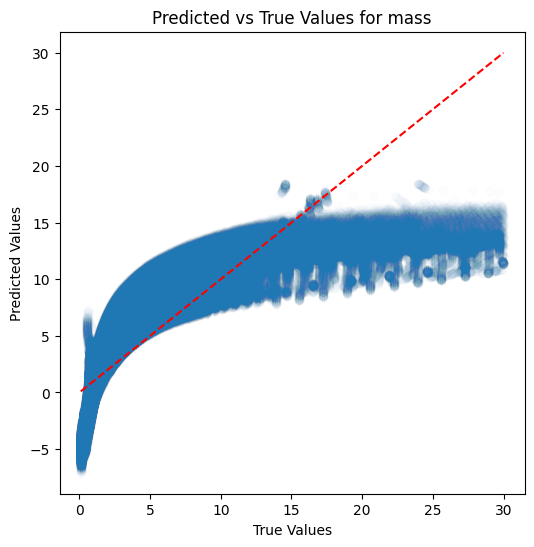

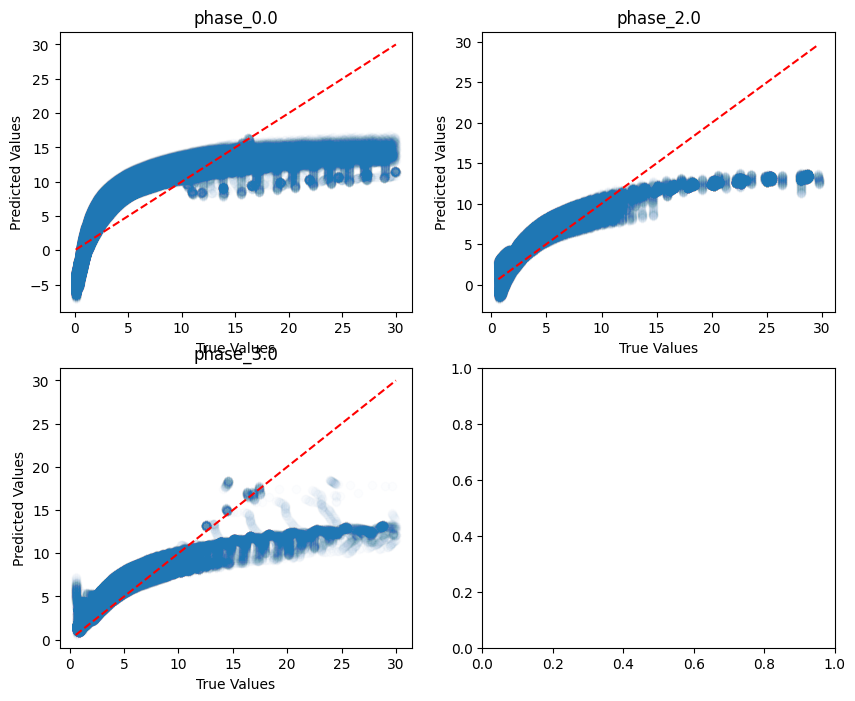

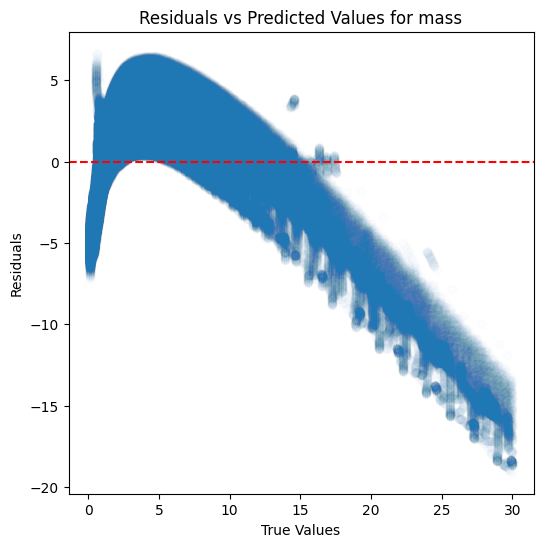

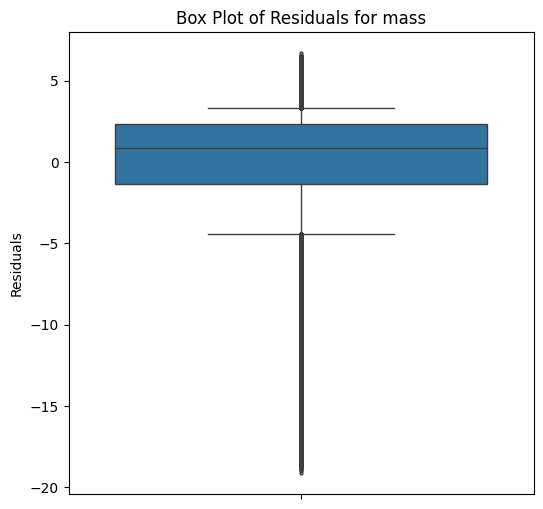

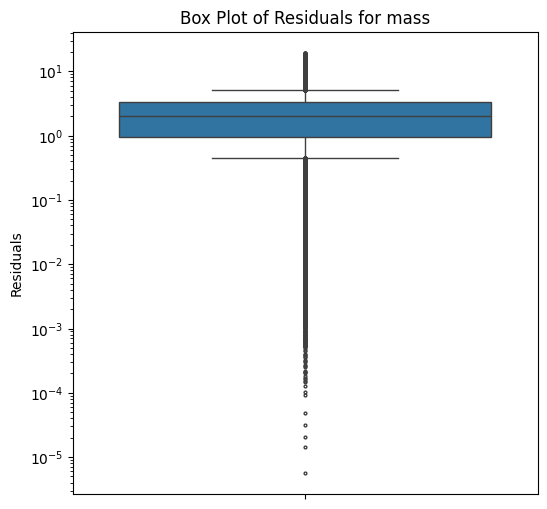

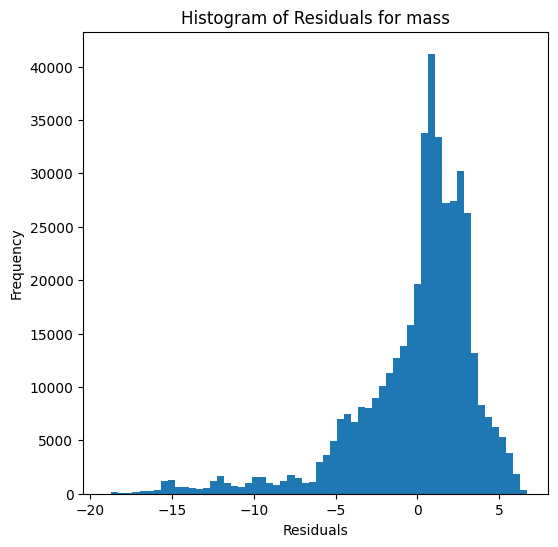

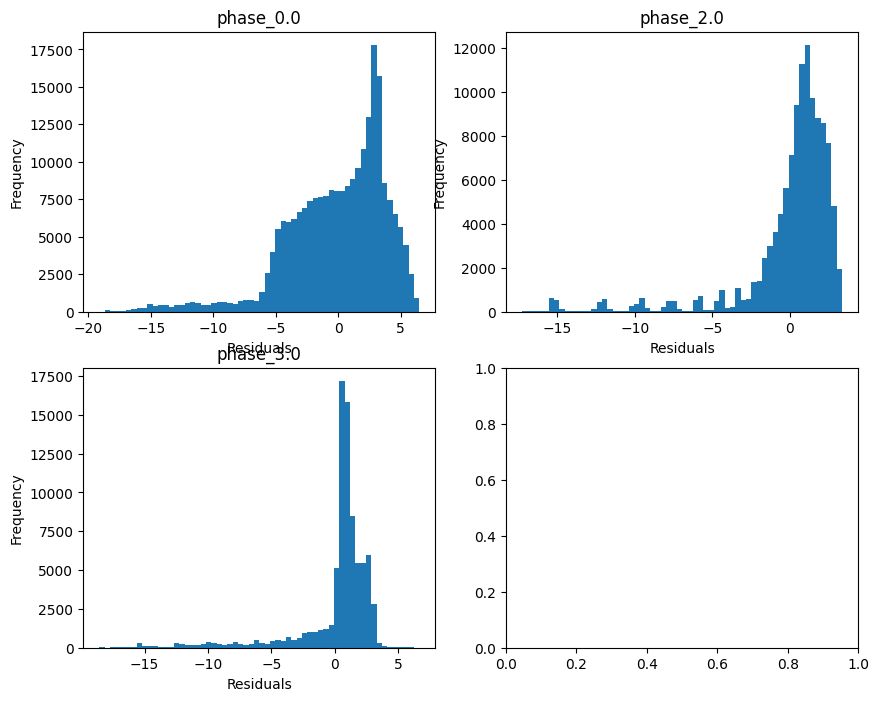

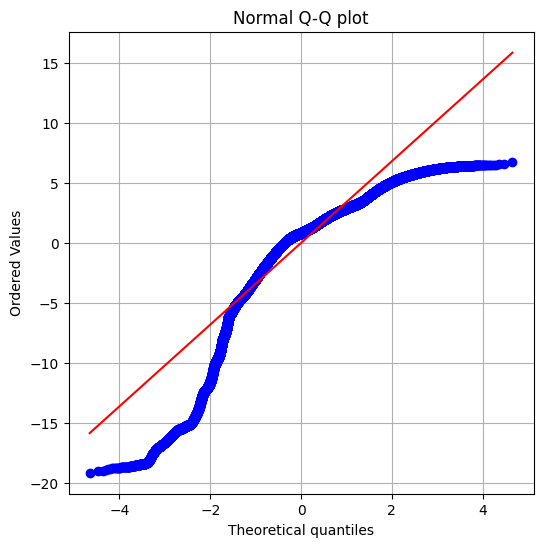

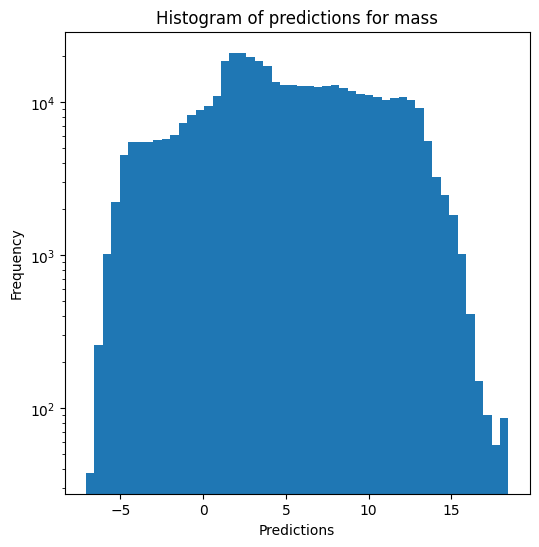

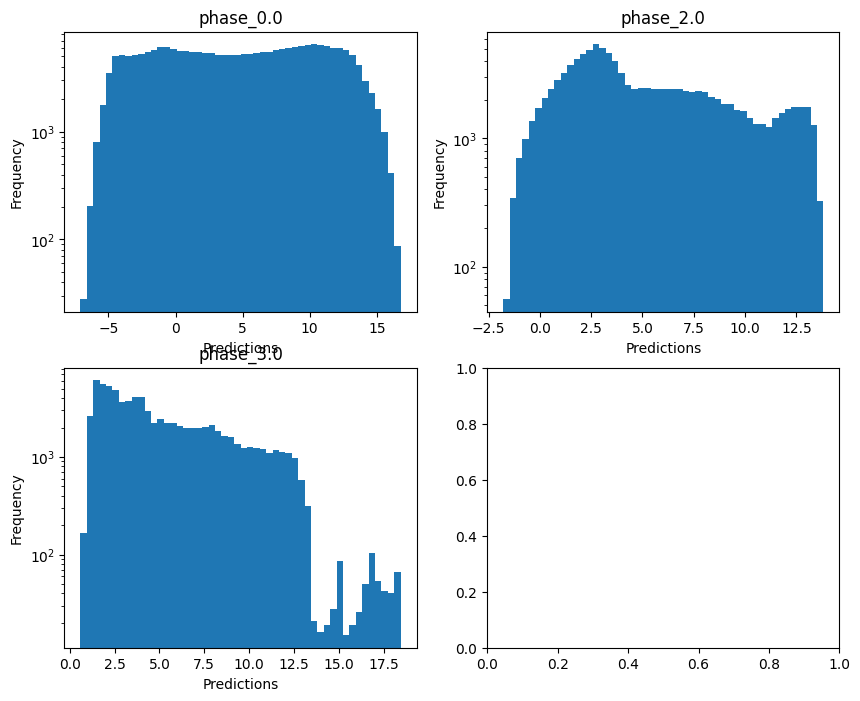

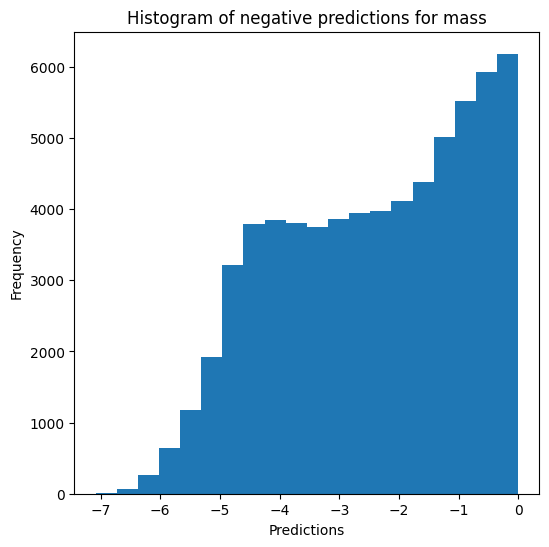


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9862122881365466
  RMSE :  0.05956995497392522
  MAE :  0.0464464445955826
  MedAE :  0.03761985989201261
  CORR :  0.9930892072248287
  MAX_ER :  0.2051926894982452
  Percentiles : 
    75th percentile :  0.0709764168852665
    90th percentile :  0.1014758244390266
    95th percentile :  0.11814575695507268
    99th percentile :  0.14670127180773437

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9801561070378554
  RMSE :  0.06498586110005262
  MAE :  0.049109073766942
  MedAE :  0.03783422218782717
  CORR :  0.9907926454524565
  MAX_ER :  0.2626936843286649
  Percentiles : 
    75th percentile :  0.07170570970313928
    90th percentile :  0.10571360620757955
    95th percentile :  0.13260082798971679
    99th percentile :  0.19206807824724073

radius results for the phase category 

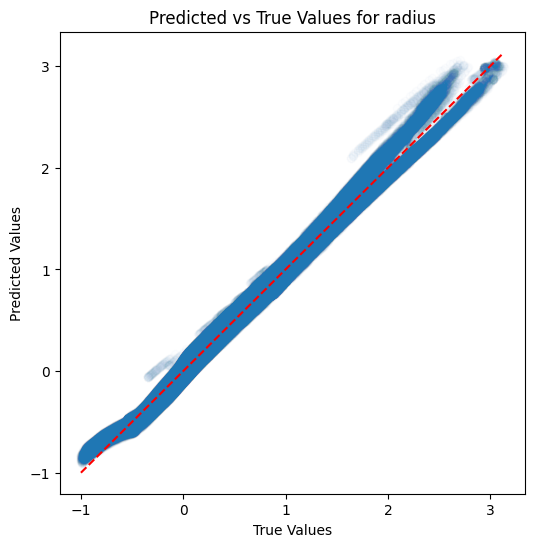

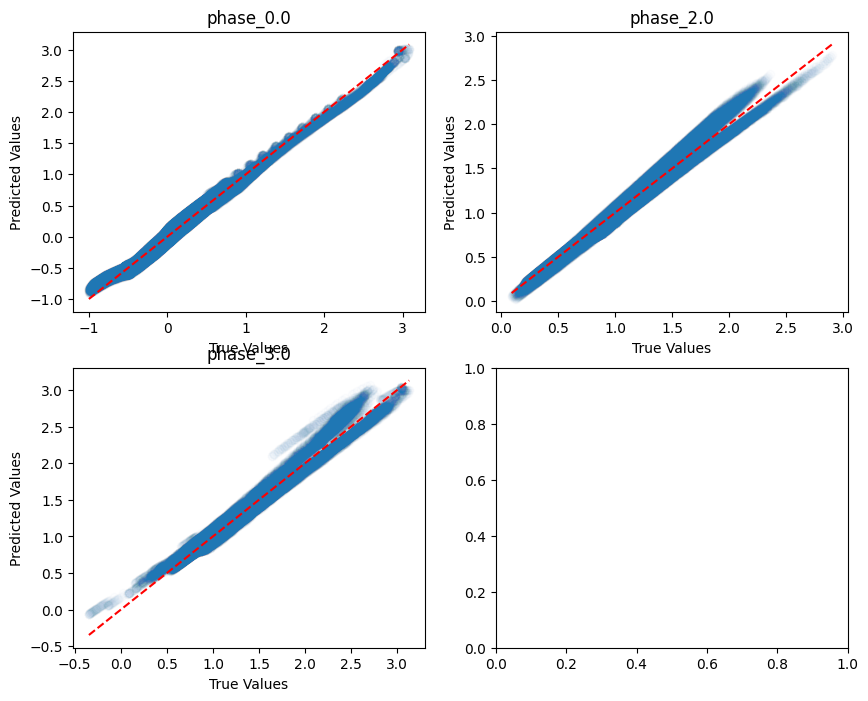

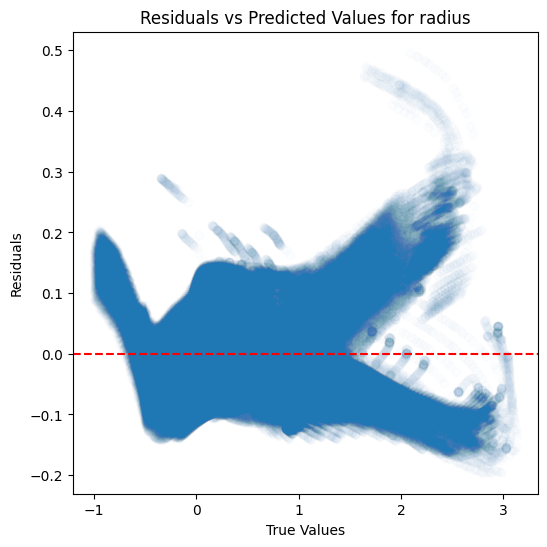

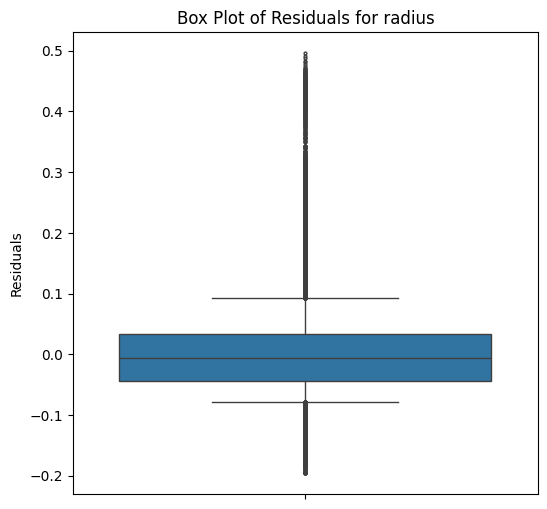

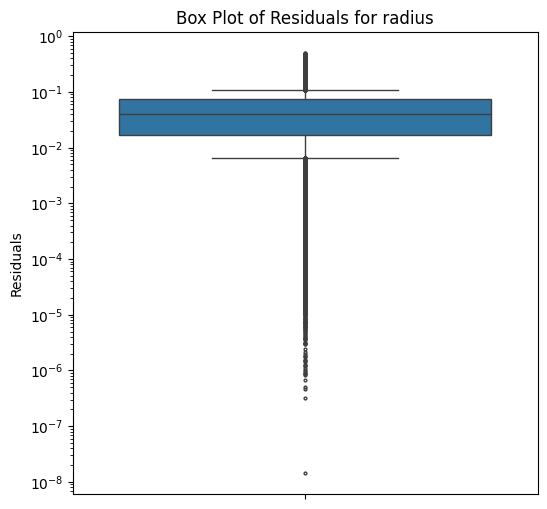

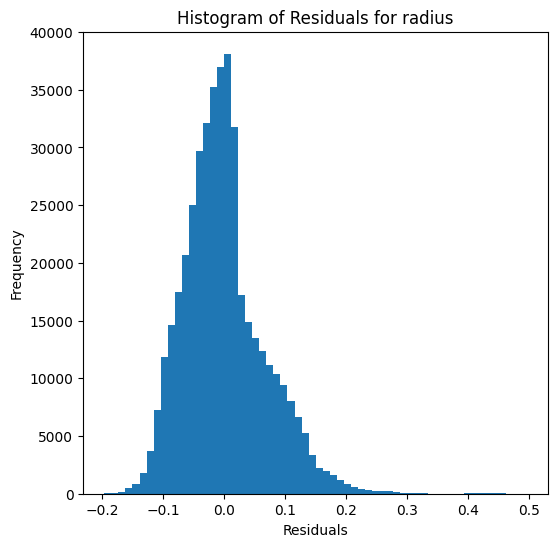

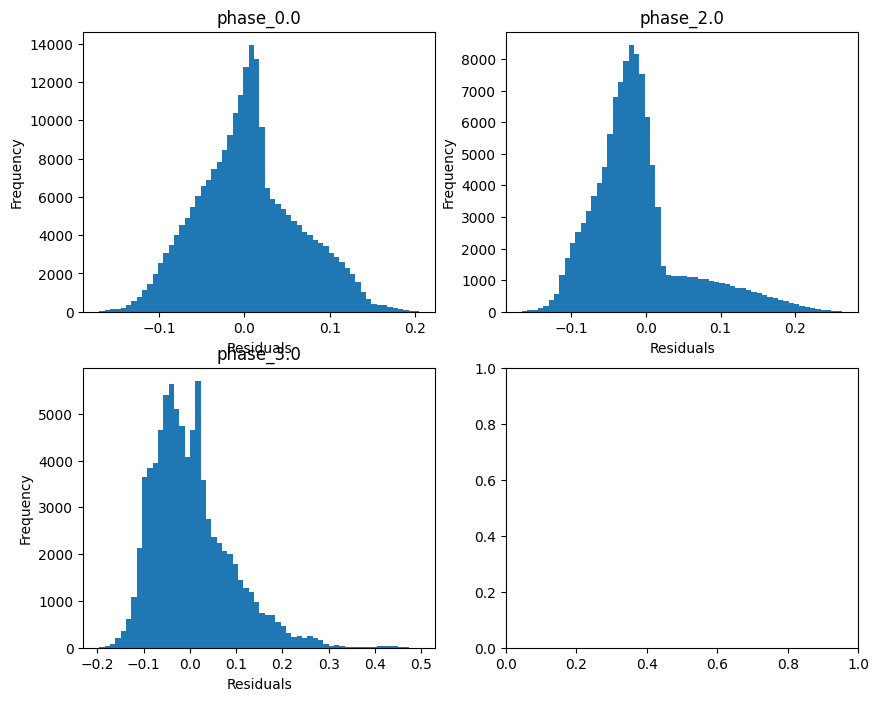

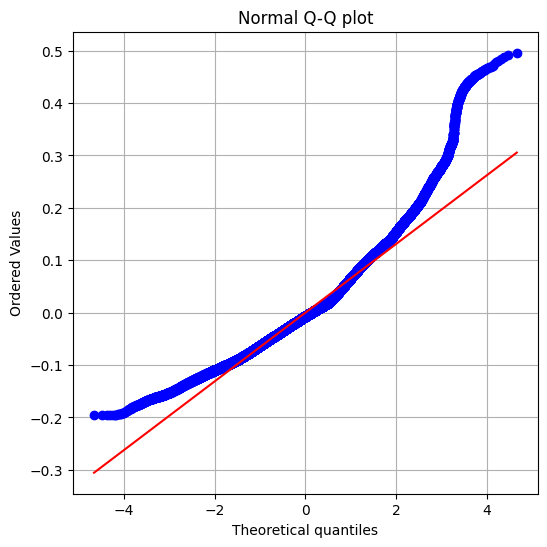

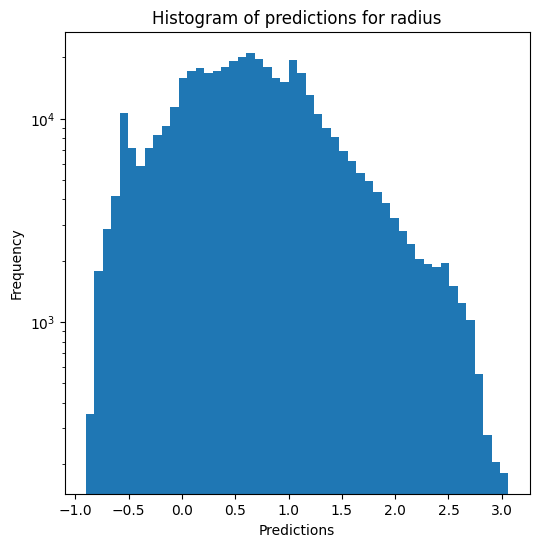

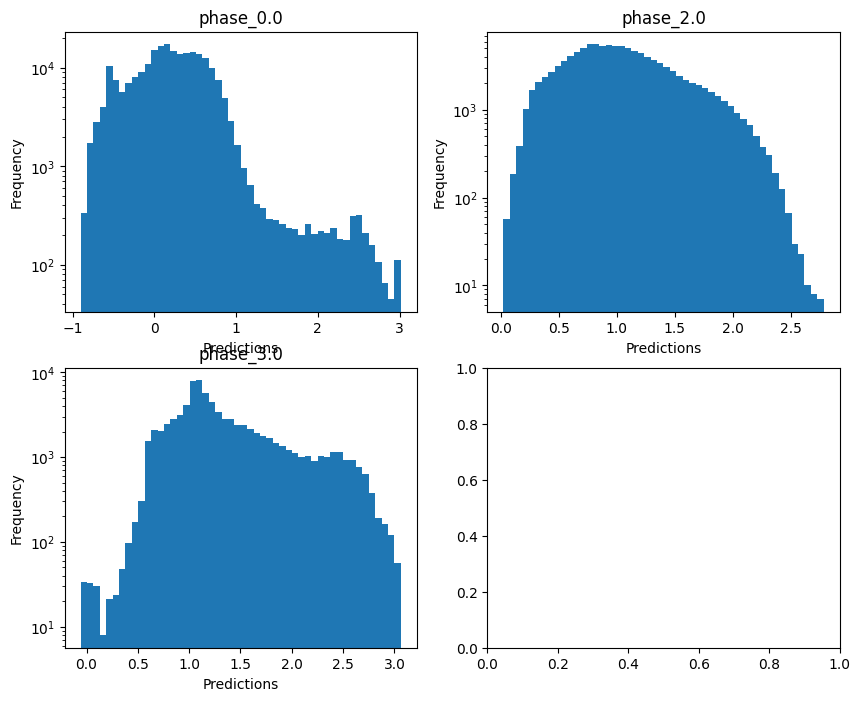

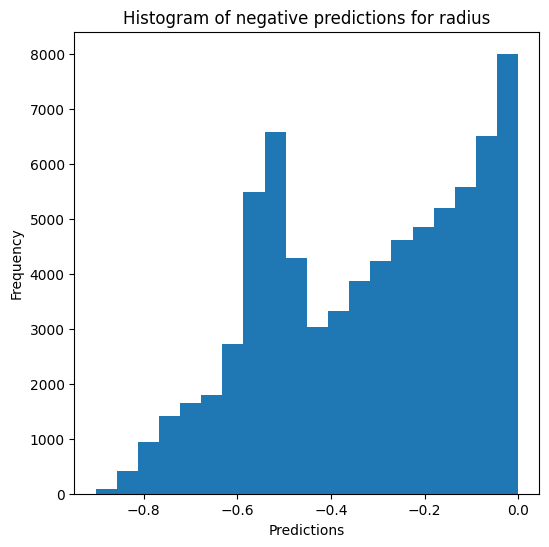

Saving predictions and results...


In [14]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show) # override=True, use_preds=False

### Decision tree

In [15]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 29.997679694990666
  RVE :  0.9988722561008796
  RMSE :  0.21011812925772266
  MAE :  0.03747717362737352
  MedAE :  0.00479855400491086
  CORR :  0.9994366029183054
  MAX_ER :  15.540236826091325
  Percentiles : 
    75th percentile :  0.018602268817705436
    90th percentile :  0.06849480845025796
    95th percentile :  0.1408180910914183
    99th percentile :  0.5222647556065607

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 29.67887151062485
  RVE :  0.9998927127269793
  RMSE :  0.06144307406556873
  MAE :  0.007676350047313216
  MedAE :  0.0002919122411721986
  CORR :  0.9999463636889504
  MAX_ER :  9.237857927278208
  Percentiles : 
    75th percentile :  0.005014644949135949
    90th percentile :  0.02200032115825365

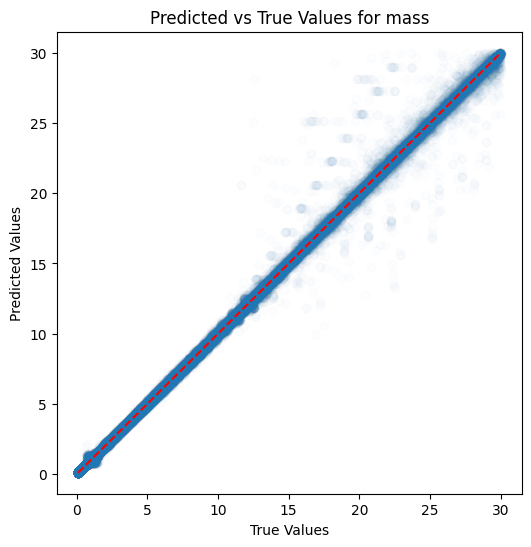

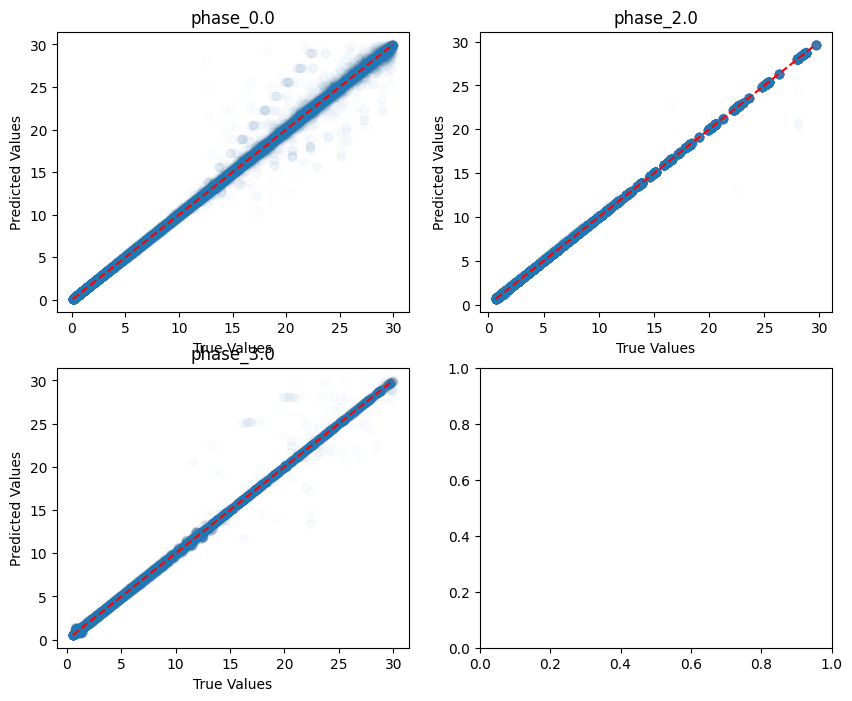

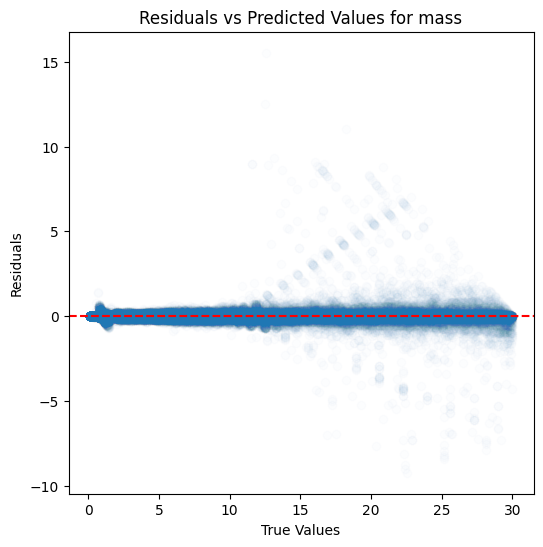

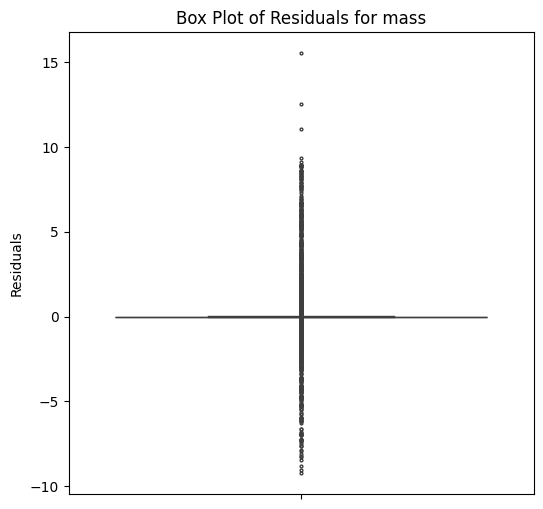

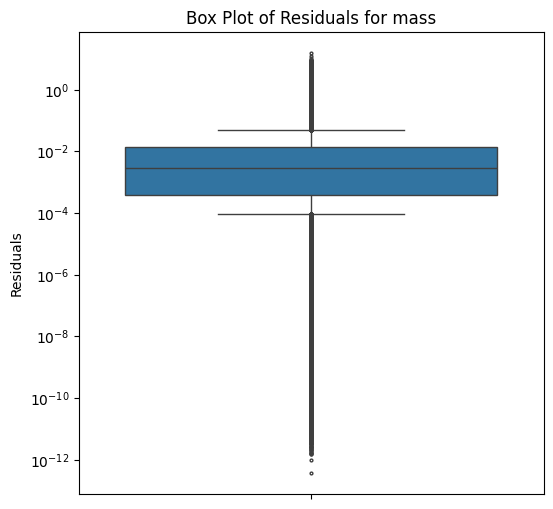

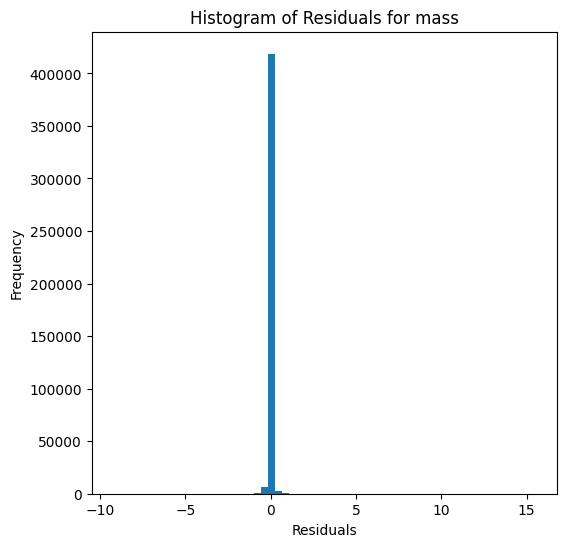

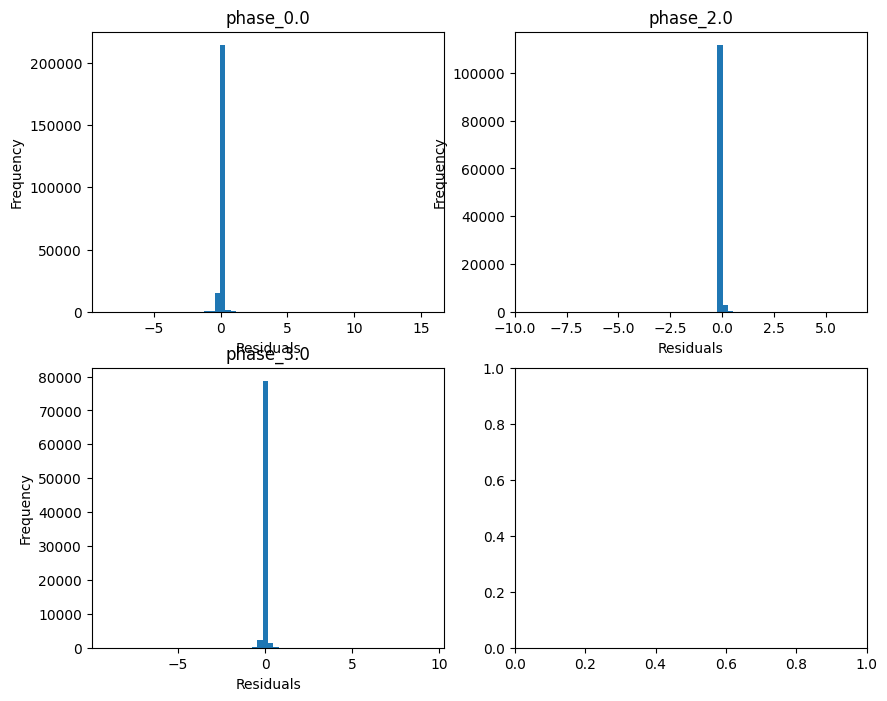

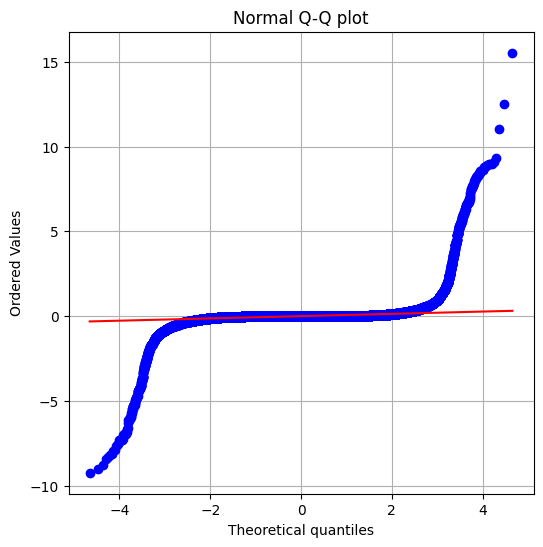

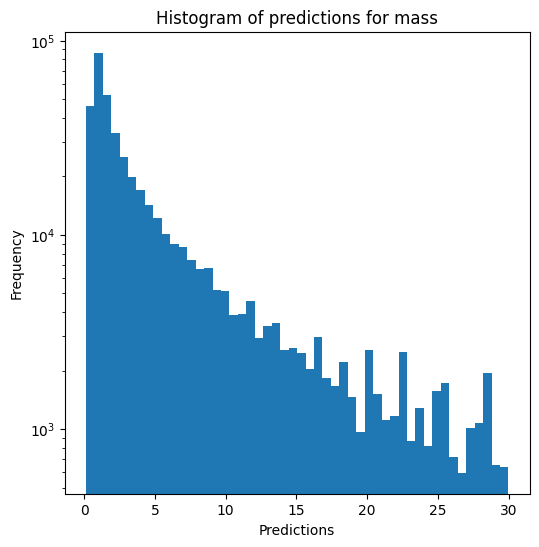

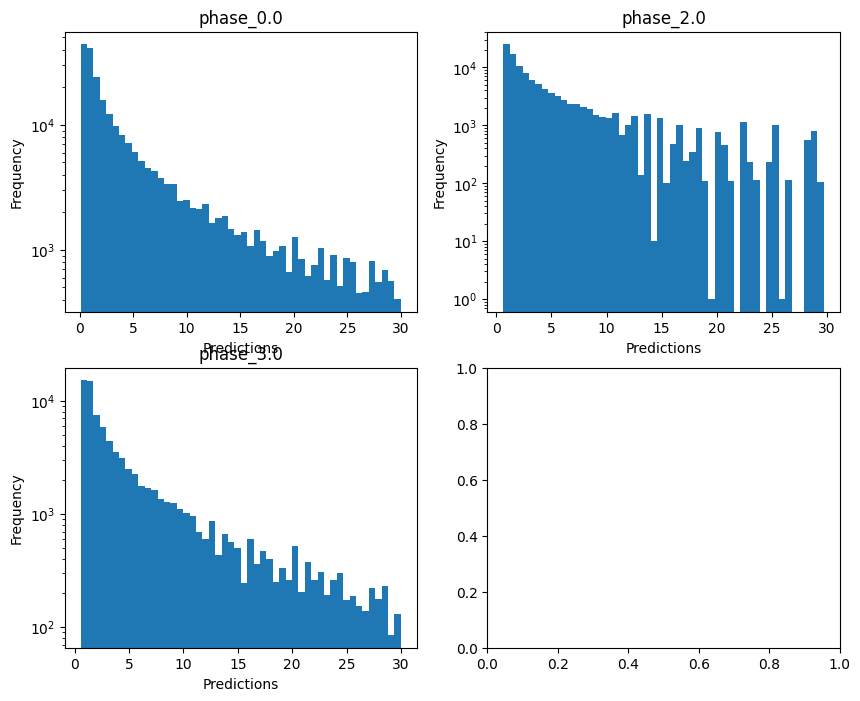


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9997969300603281
  RMSE :  0.007210909501552653
  MAE :  0.003990487994109026
  MedAE :  0.0024217307044735945
  CORR :  0.999898462338922
  MAX_ER :  0.7063874704350424
  Percentiles : 
    75th percentile :  0.004854568362242281
    90th percentile :  0.008880702272495489
    95th percentile :  0.012511845660491435
    99th percentile :  0.026826488212296513

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9995266839683316
  RMSE :  0.009894219329654542
  MAE :  0.0069290067863933495
  MedAE :  0.005589242303922437
  CORR :  0.9997651809159842
  MAX_ER :  0.20345689034944625
  Percentiles : 
    75th percentile :  0.009415987572847673
    90th percentile :  0.013591066155273345
    95th percentile :  0.016684685955259338
    99th percentile :  0.031041042404434272

radius results fo

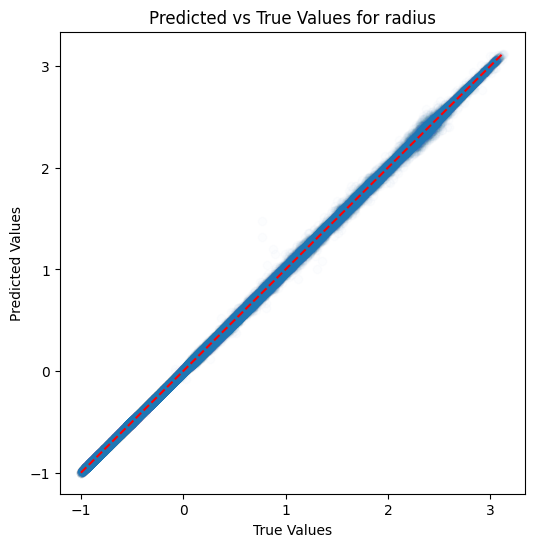

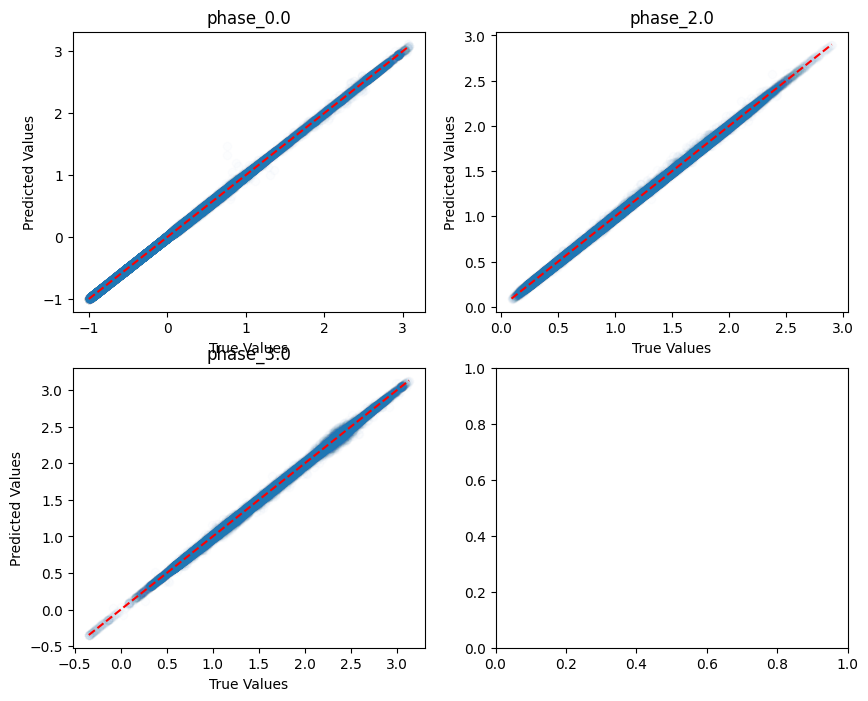

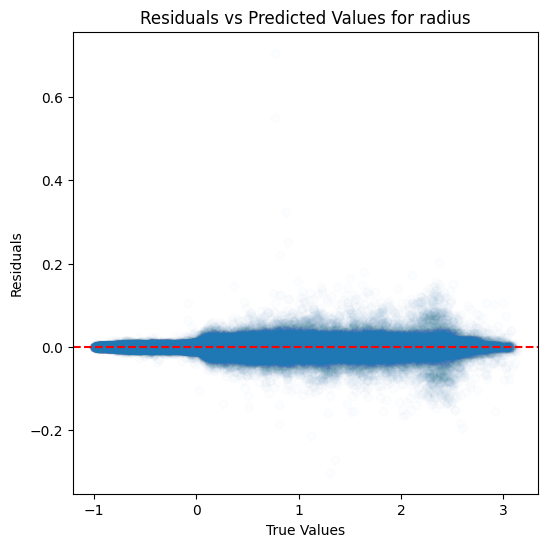

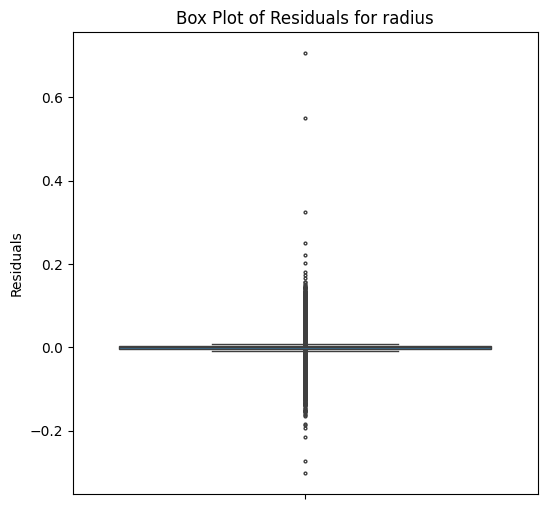

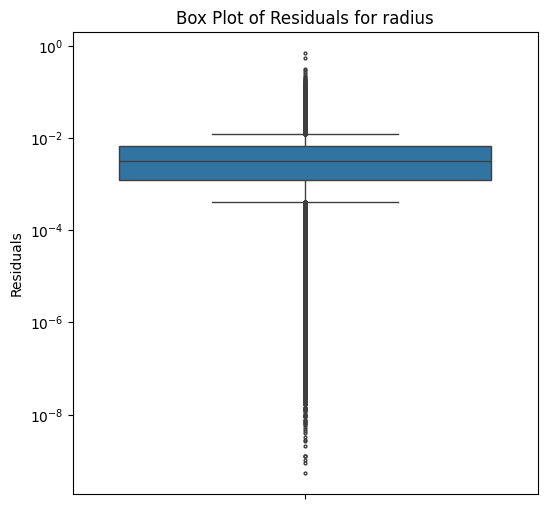

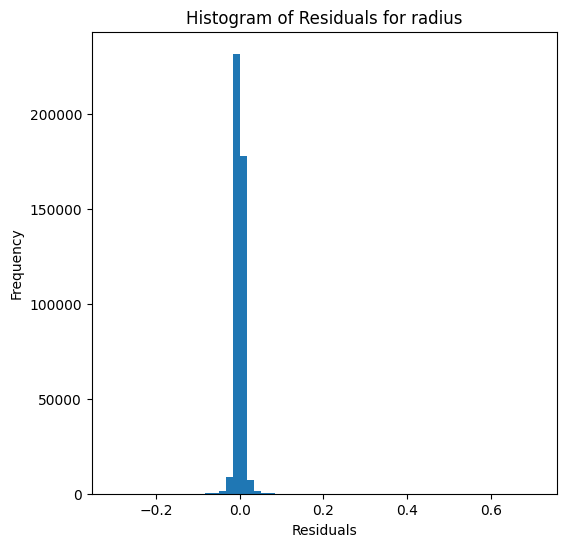

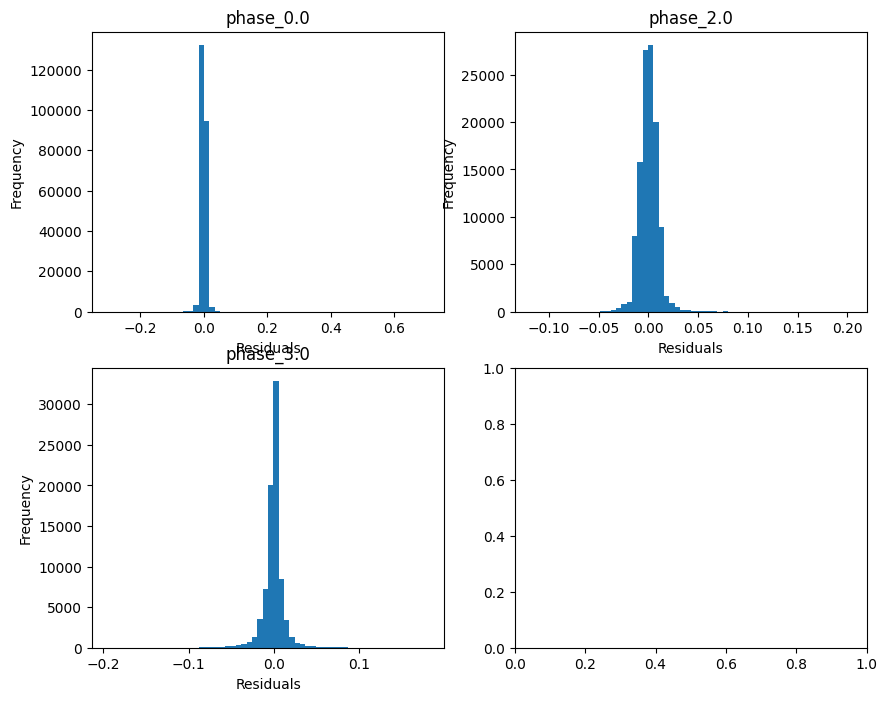

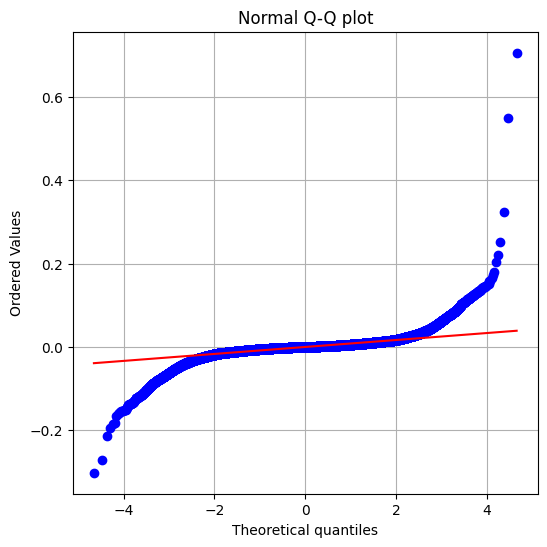

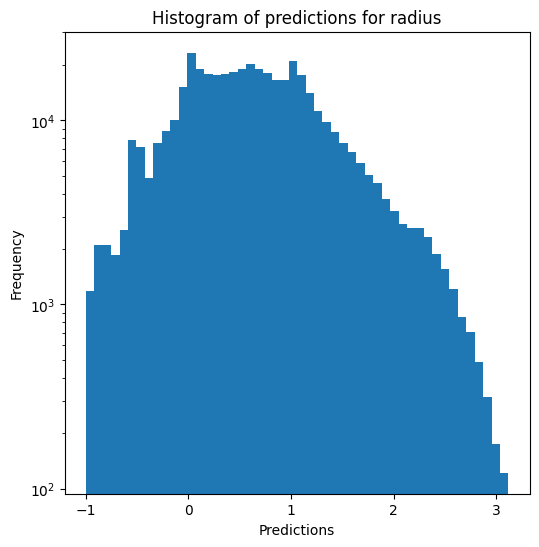

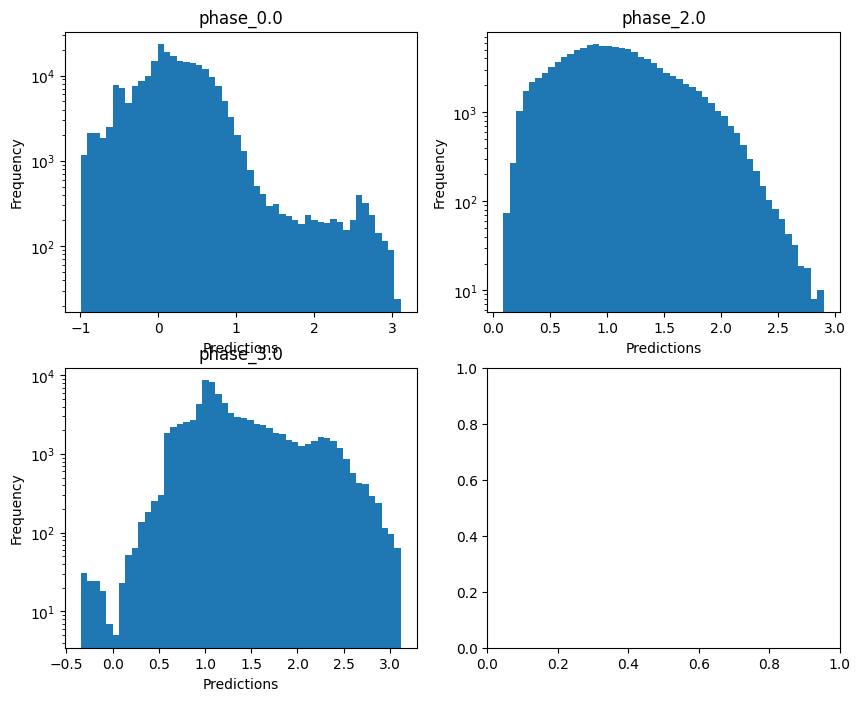

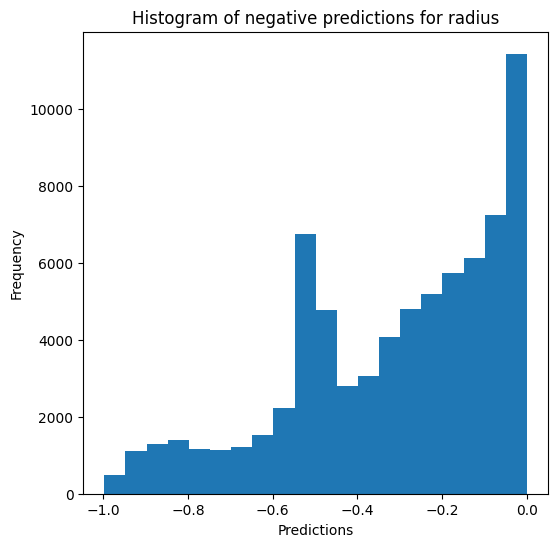

Saving predictions and results...


In [16]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### K-nearest neighbours

In [17]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 29.997679694990666
  RVE :  0.9983227260594209
  RMSE :  0.25636885361246897
  MAE :  0.06405473549148975
  MedAE :  0.00842977392881844
  CORR :  0.9991751174974345
  MAX_ER :  6.561332948493394
  Percentiles : 
    75th percentile :  0.03345040061997495
    90th percentile :  0.1222658610693556
    95th percentile :  0.2647270677289495
    99th percentile :  1.0026418084493463

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 29.67887151062485
  RVE :  0.9998957487907331
  RMSE :  0.060616498618364115
  MAE :  0.020233452970197227
  MedAE :  0.003641185388460144
  CORR :  0.9999479221527767
  MAX_ER :  2.368225409023001
  Percentiles : 
    75th percentile :  0.015041722302887806
    90th percentile :  0.05275069021391478
  

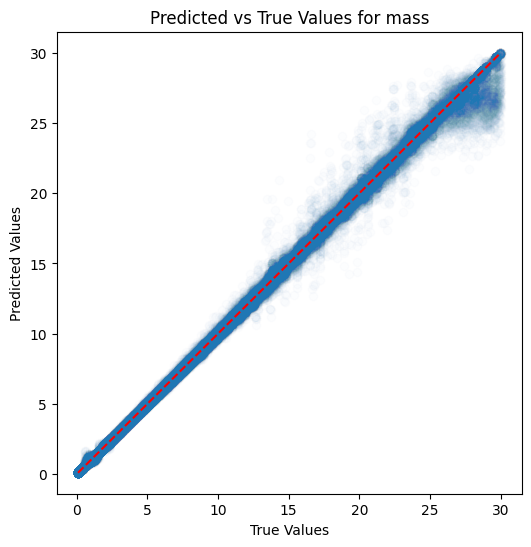

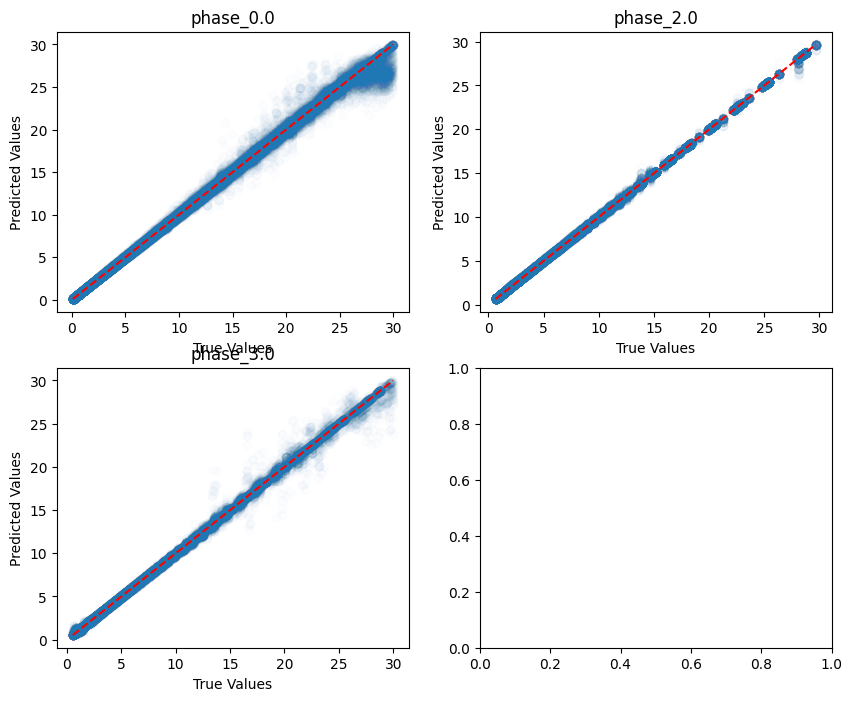

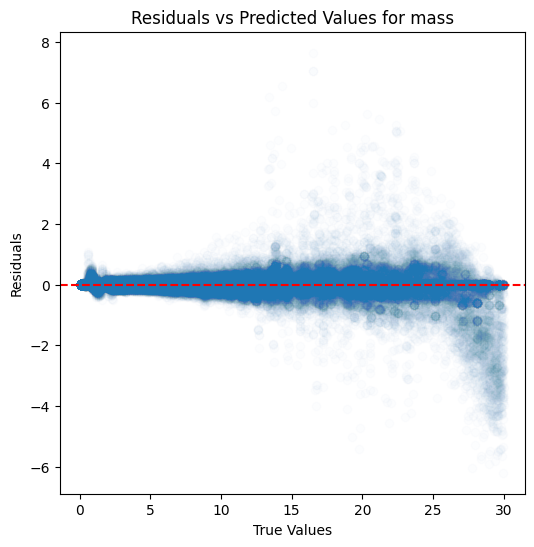

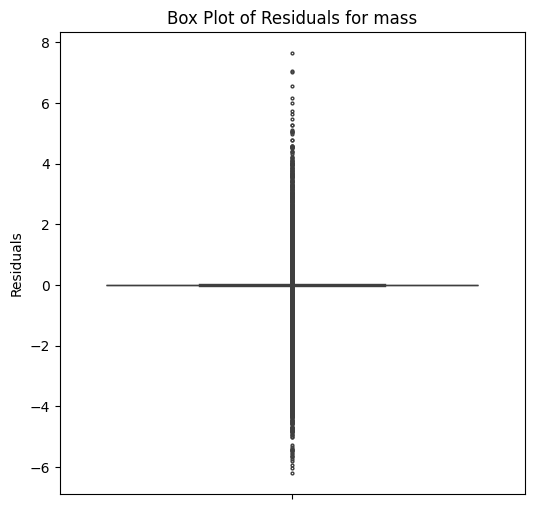

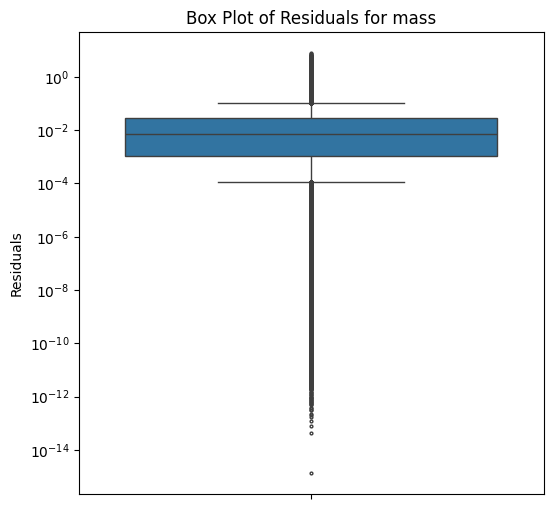

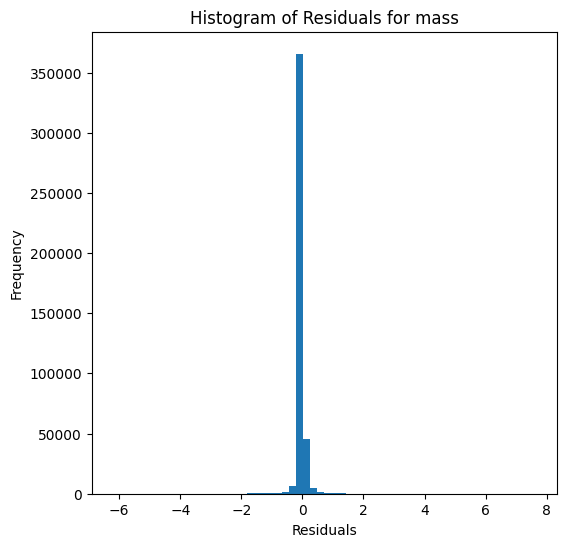

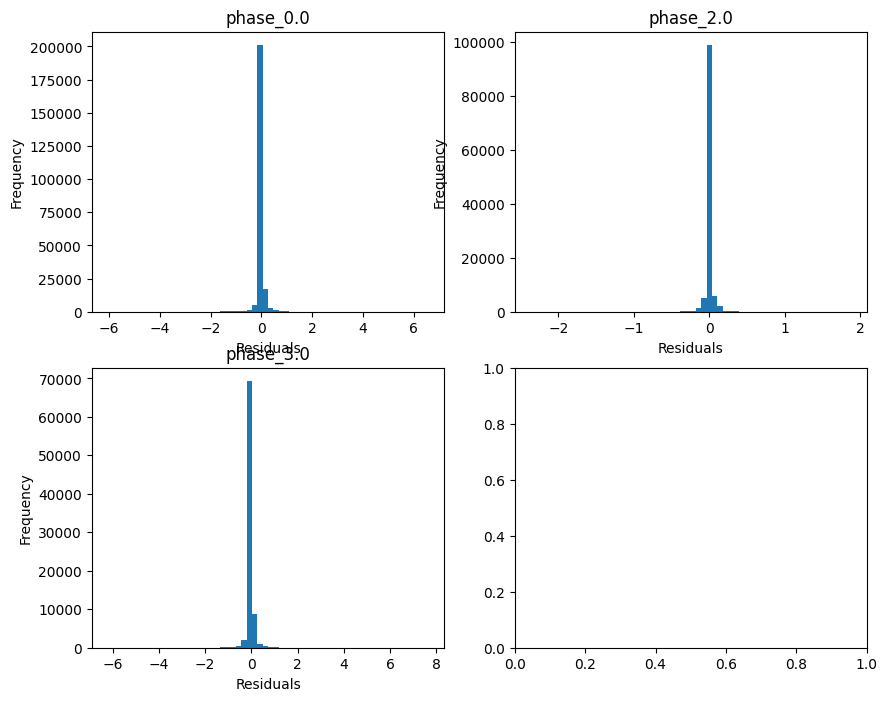

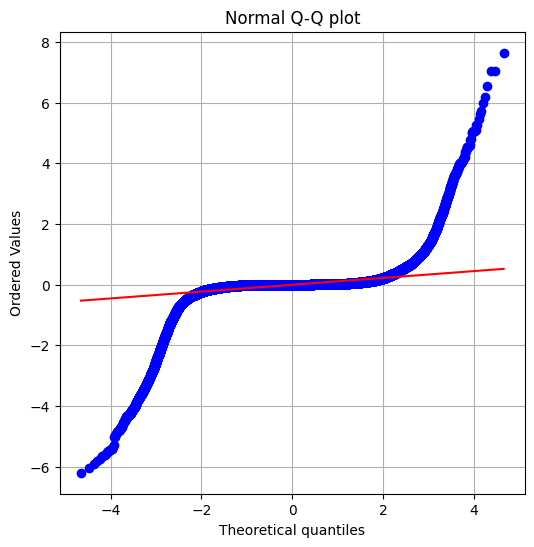

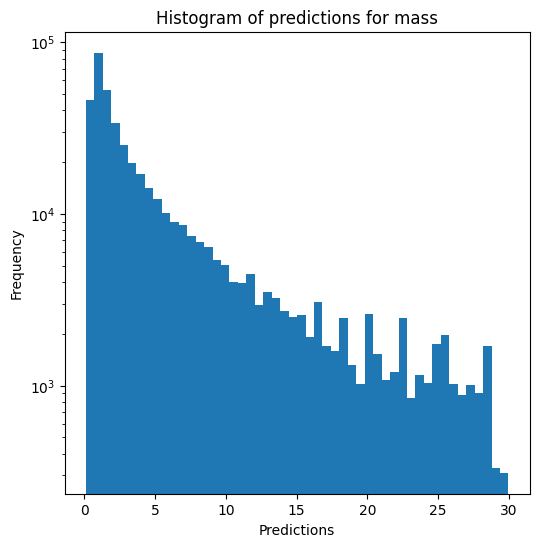

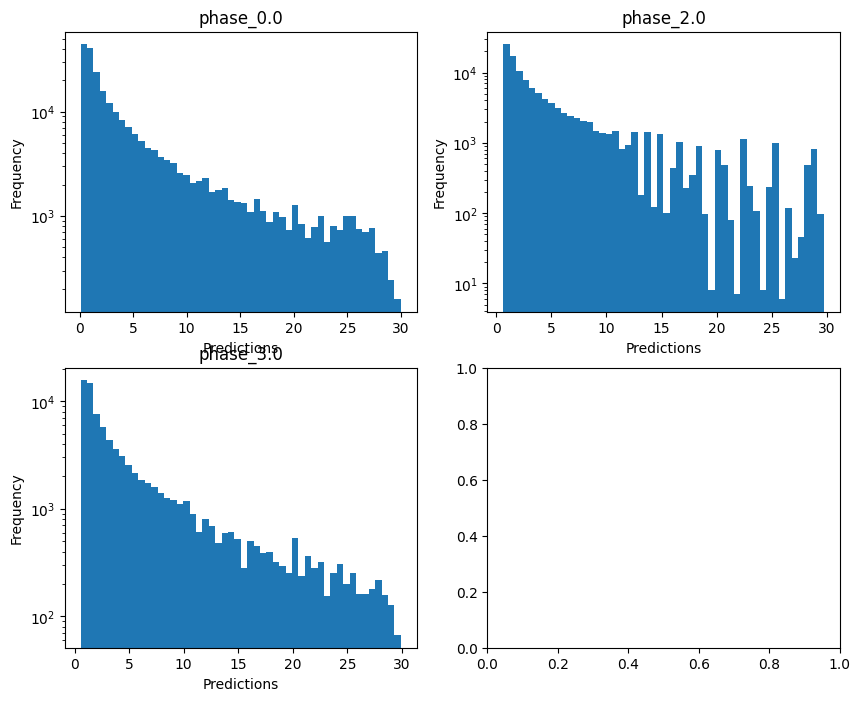


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9998699911918713
  RMSE :  0.005767861390962687
  MAE :  0.0037608413931162613
  MedAE :  0.002432333521750041
  CORR :  0.9999353240819183
  MAX_ER :  0.07189388749938058
  Percentiles : 
    75th percentile :  0.004728121957159673
    90th percentile :  0.008591390763160062
    95th percentile :  0.011889612689004358
    99th percentile :  0.021658646359189748

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9998962596584994
  RMSE :  0.004630230273009741
  MAE :  0.0034745679773636913
  MedAE :  0.0026377760360715152
  CORR :  0.9999481574096413
  MAX_ER :  0.054523387713812266
  Percentiles : 
    75th percentile :  0.004762626574262407
    90th percentile :  0.007697062277693421
    95th percentile :  0.009606616787986287
    99th percentile :  0.013526463894253785

radius result

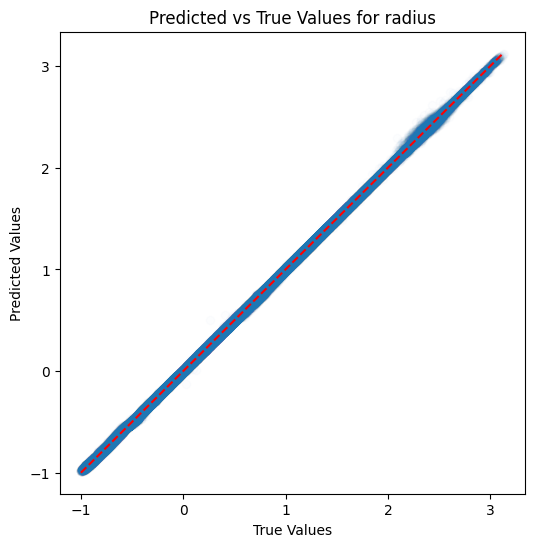

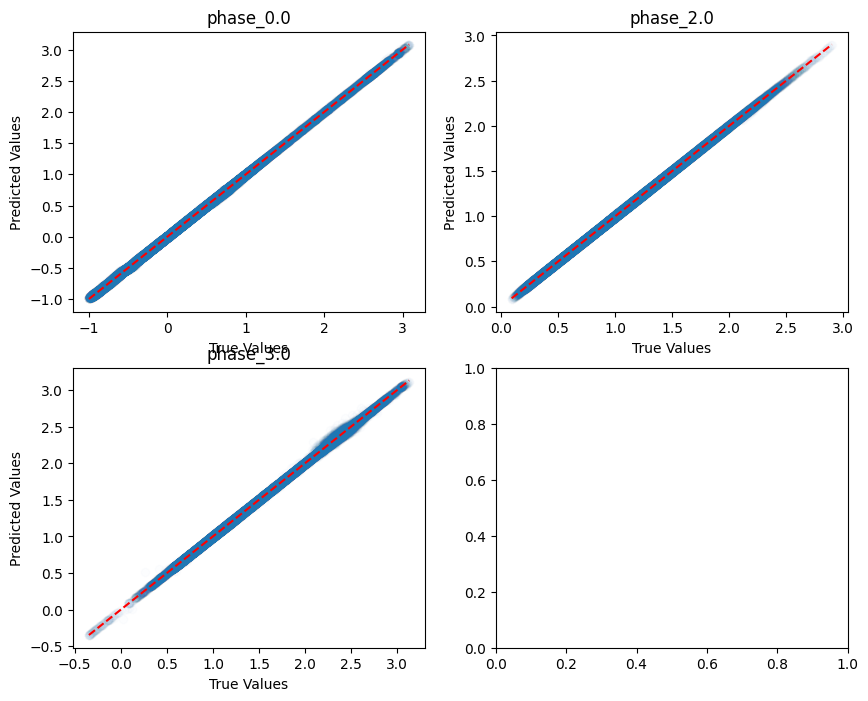

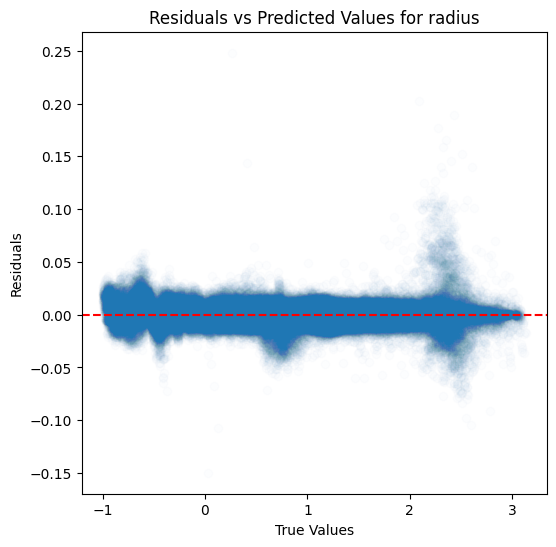

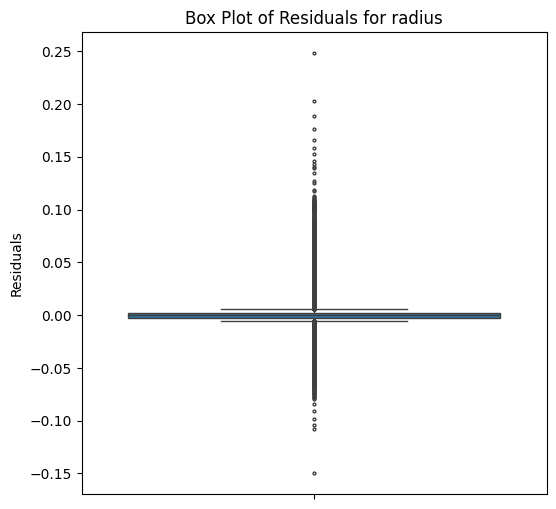

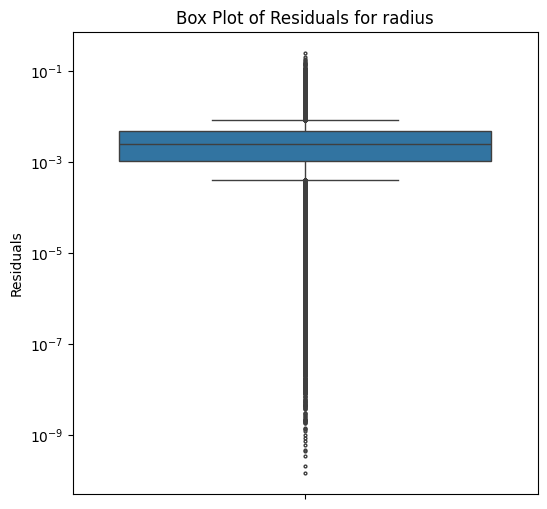

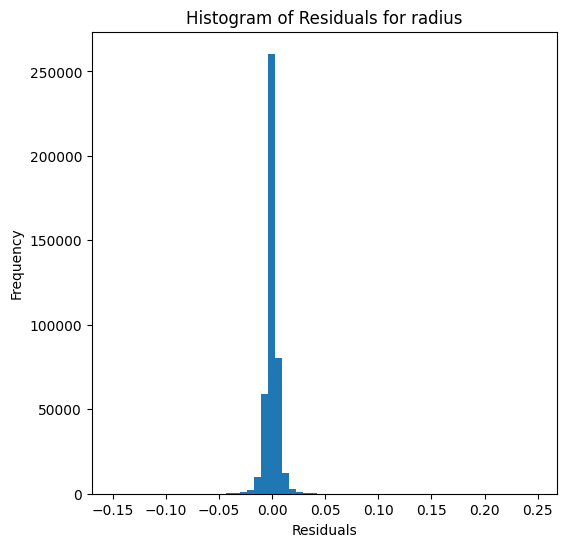

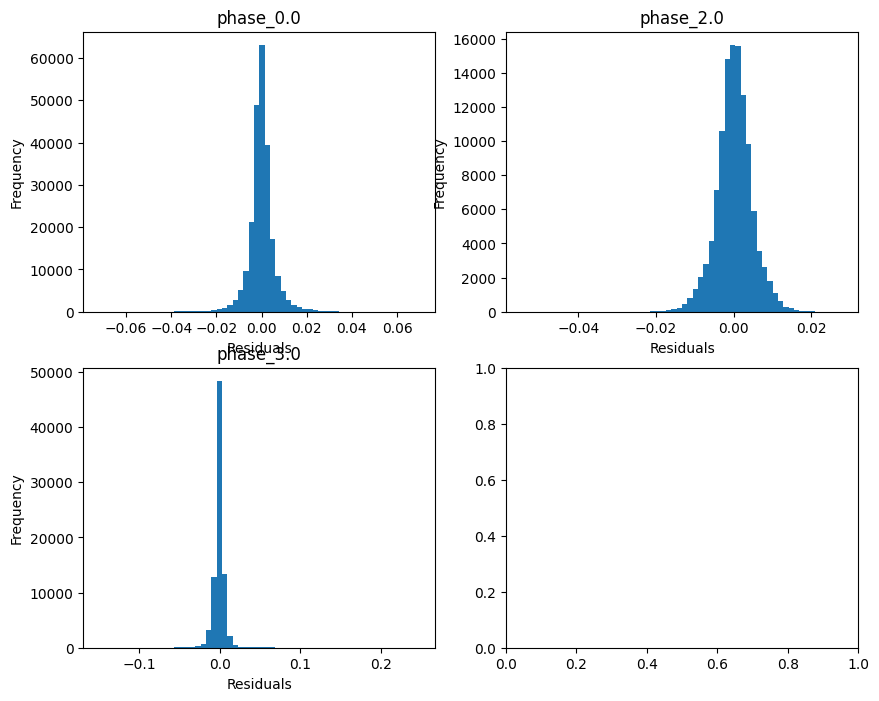

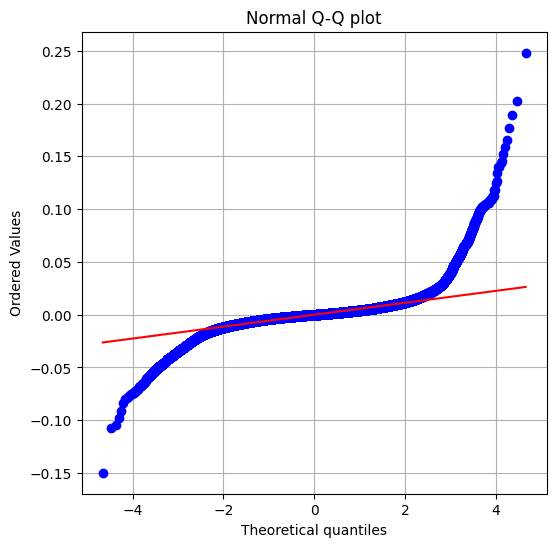

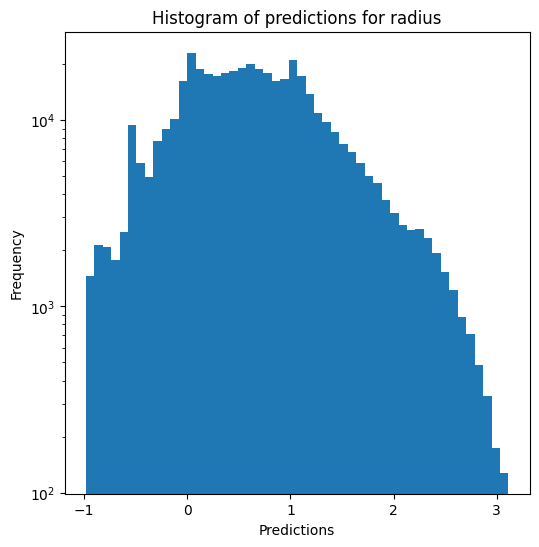

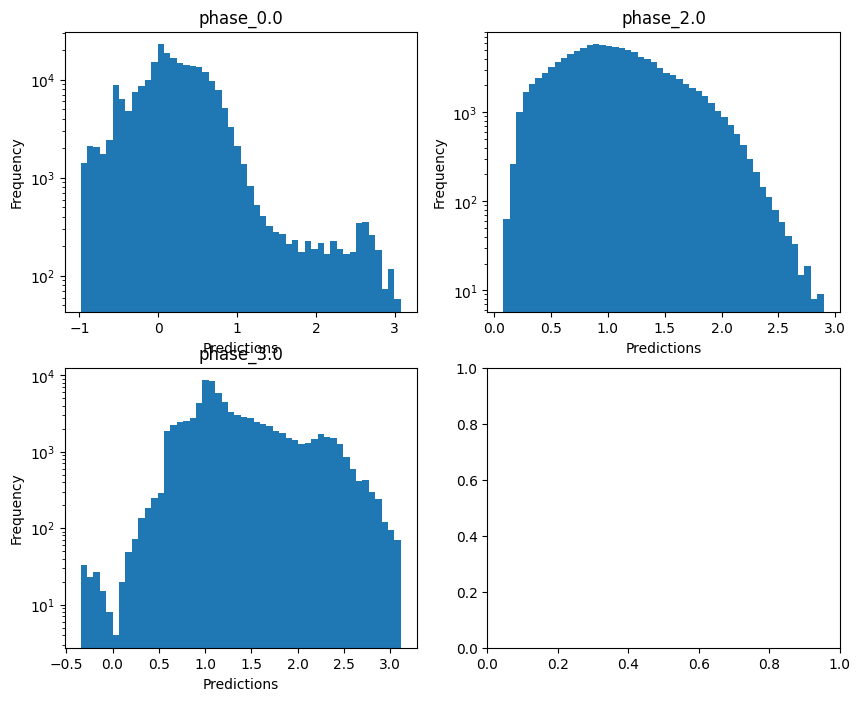

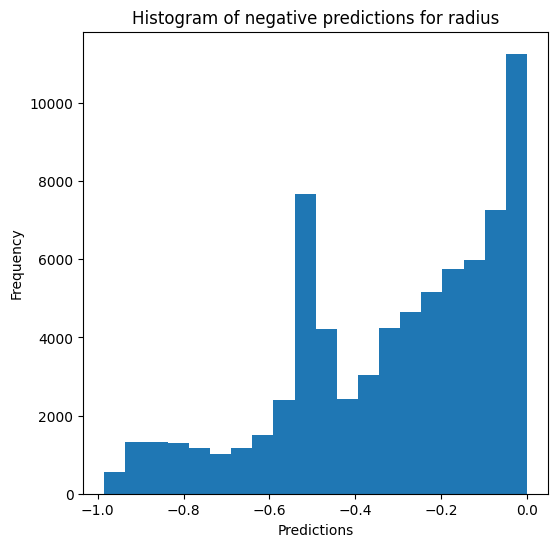

Saving predictions and results...


In [18]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### Random forests

In [19]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 29.997679694990666
  RVE :  0.999521993790828
  RMSE :  0.13680570665551384
  MAE :  0.02316684897867771
  MedAE :  0.0027835813211130045
  CORR :  0.9997609878413475
  MAX_ER :  7.625138729369718
  Percentiles : 
    75th percentile :  0.00962686556517256
    90th percentile :  0.03336080314522352
    95th percentile :  0.07566839157006429
    99th percentile :  0.37299860709643246

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 29.67887151062485
  RVE :  0.9999690893306589
  RMSE :  0.03298973331319178
  MAE :  0.008392105851517322
  MedAE :  0.0038752418231038366
  CORR :  0.999984609078679
  MAX_ER :  3.9674776262925953
  Percentiles : 
    75th percentile :  0.009191690597138091
    90th percentile :  0.0176373100883743

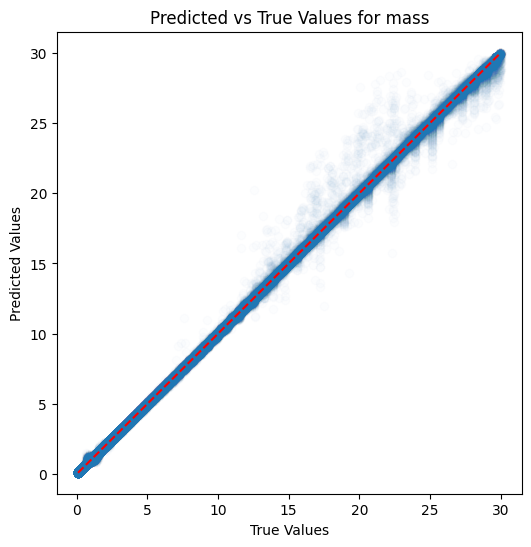

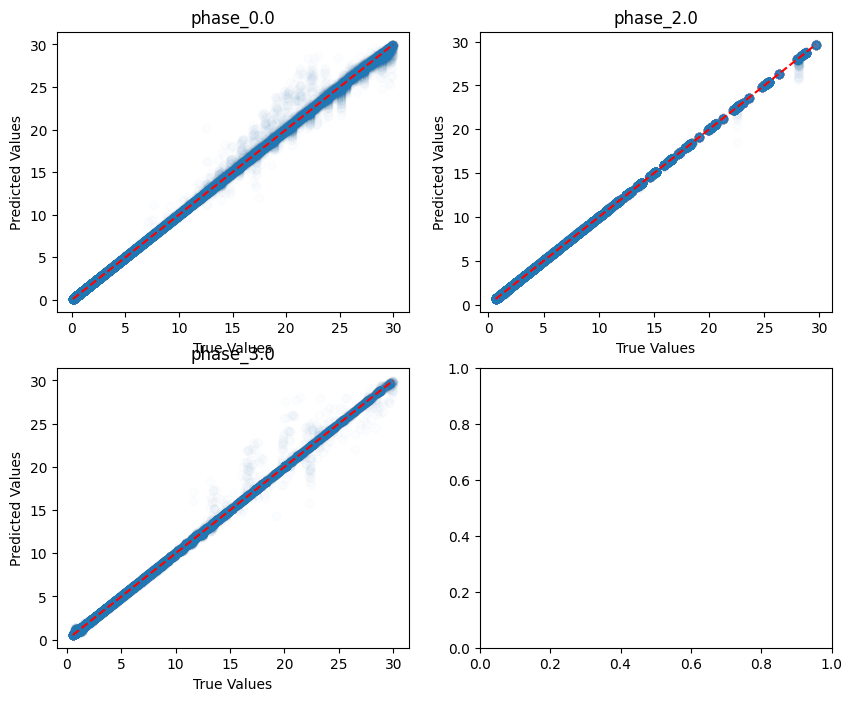

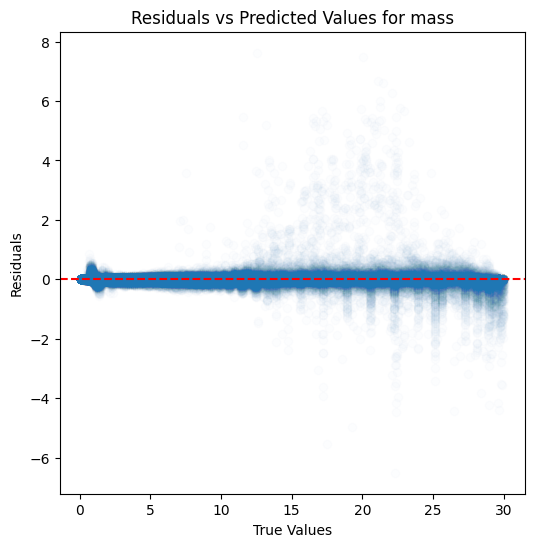

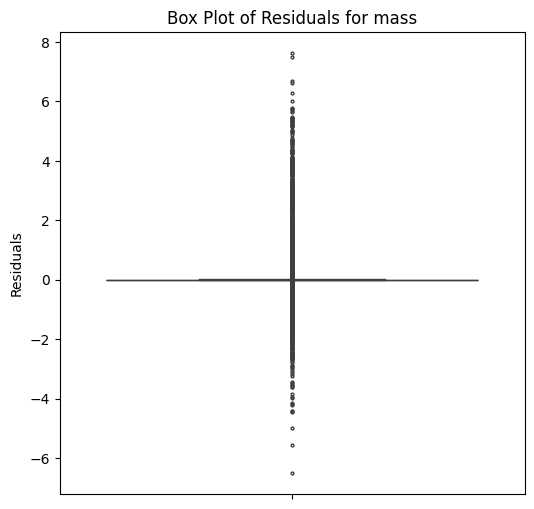

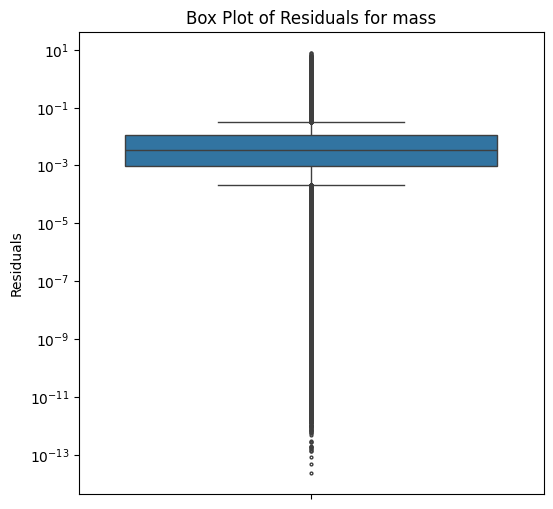

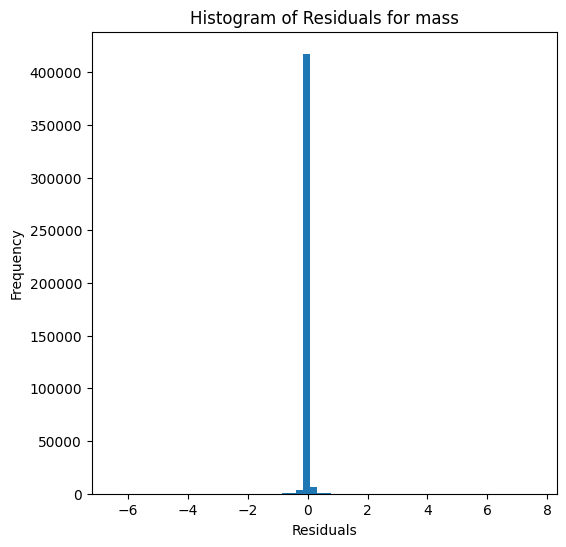

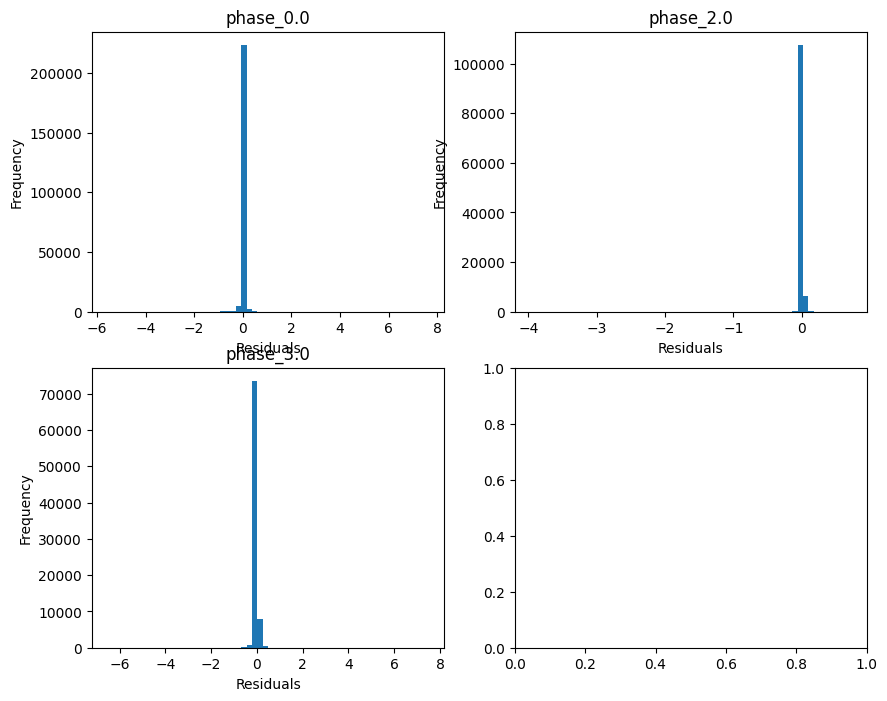

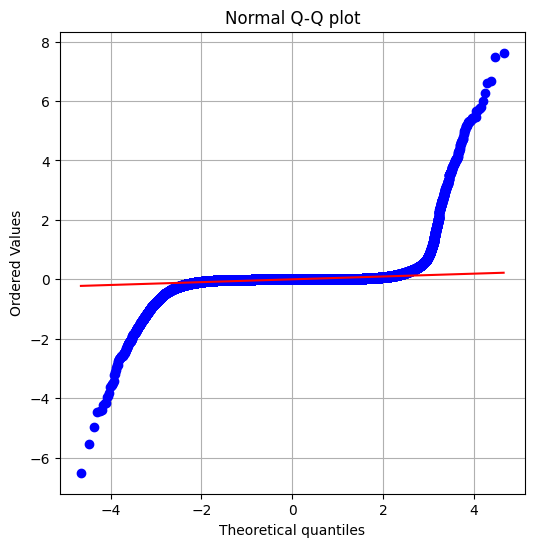

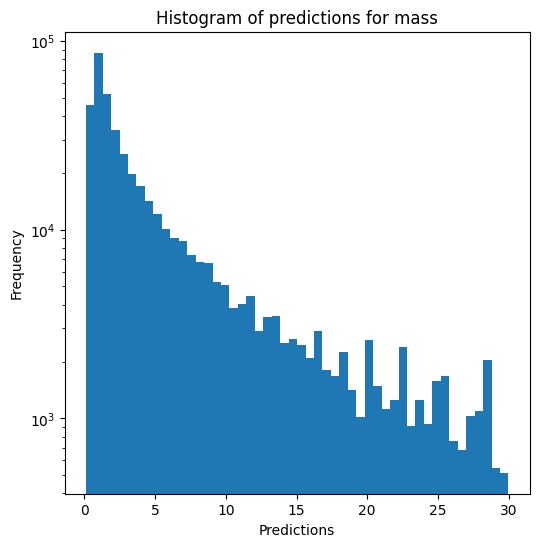

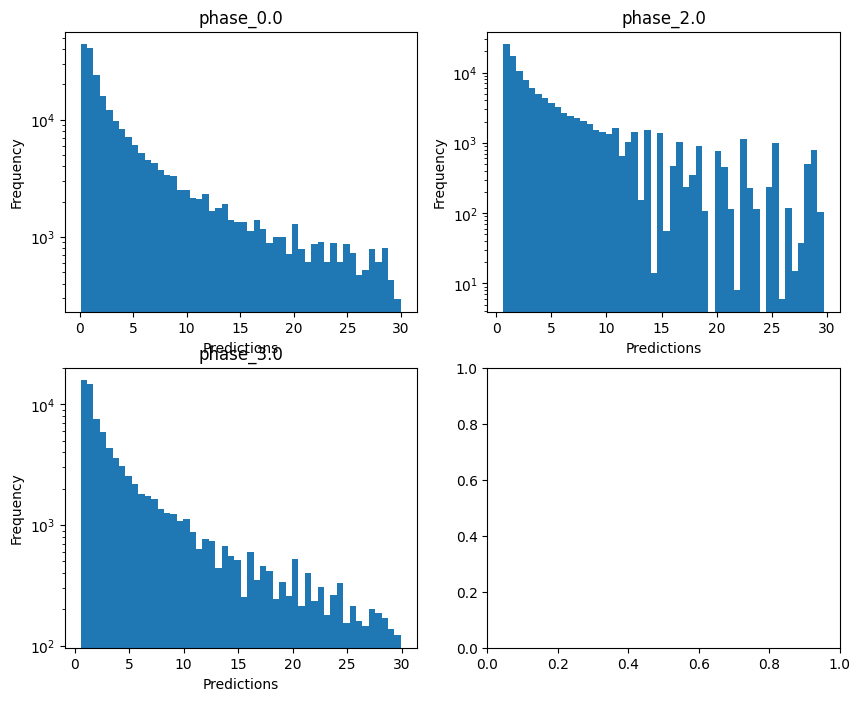


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999559178590984
  RMSE :  0.003360076492135555
  MAE :  0.0017485554593707224
  MedAE :  0.0009219322498785444
  CORR :  0.9999779588394017
  MAX_ER :  0.41081598171253786
  Percentiles : 
    75th percentile :  0.0020375011734008984
    90th percentile :  0.004049819838513752
    95th percentile :  0.006078865997045531
    99th percentile :  0.012820790010886336

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9999308463547795
  RMSE :  0.0038178736112062105
  MAE :  0.0026058014601922598
  MedAE :  0.0017584537639194764
  CORR :  0.9999665535016122
  MAX_ER :  0.05041718676265505
  Percentiles : 
    75th percentile :  0.003520413881770601
    90th percentile :  0.00595862825392679
    95th percentile :  0.007869136814848528
    99th percentile :  0.012896371478214166

radius resul

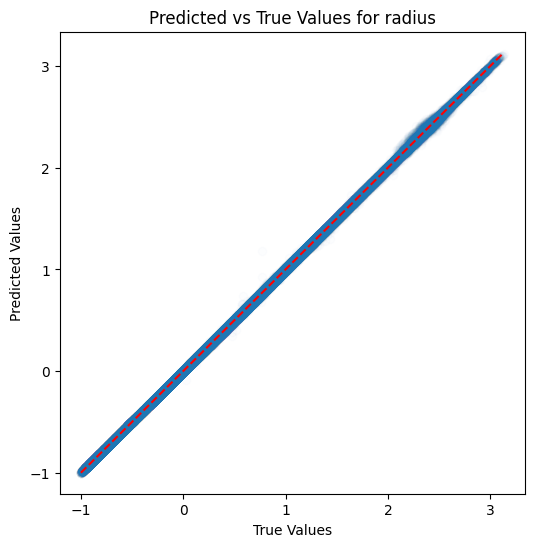

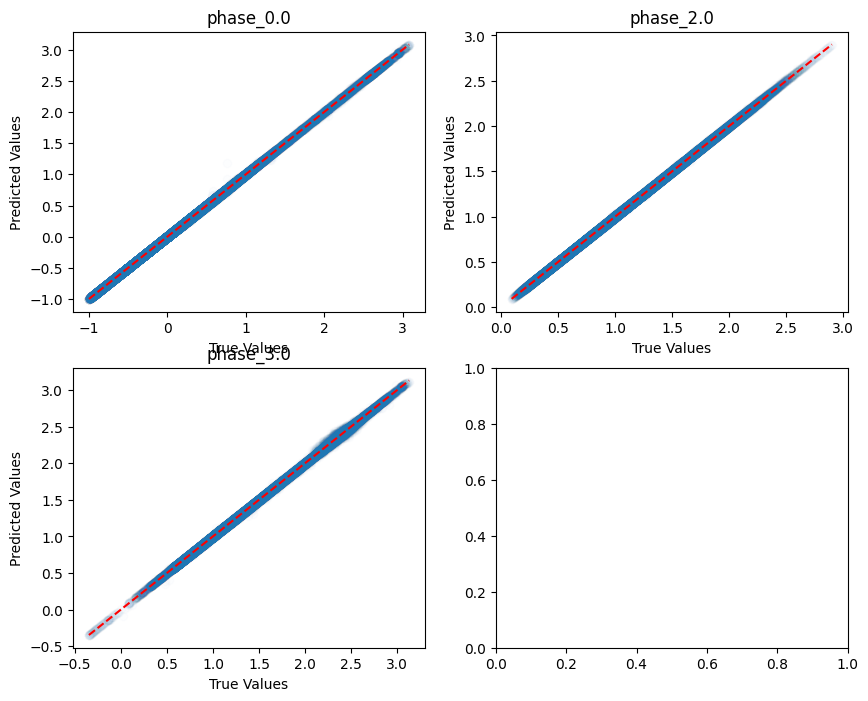

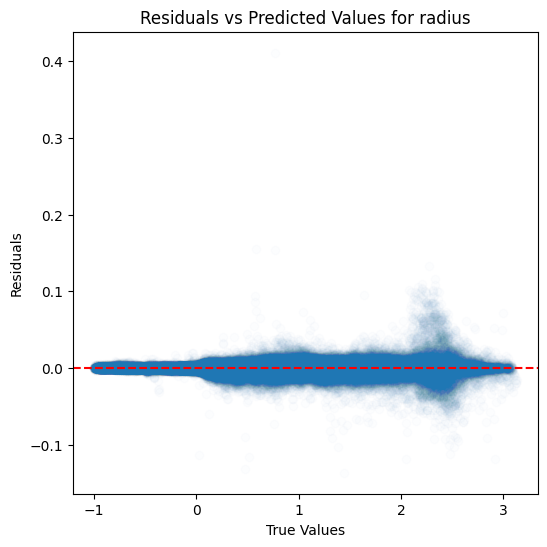

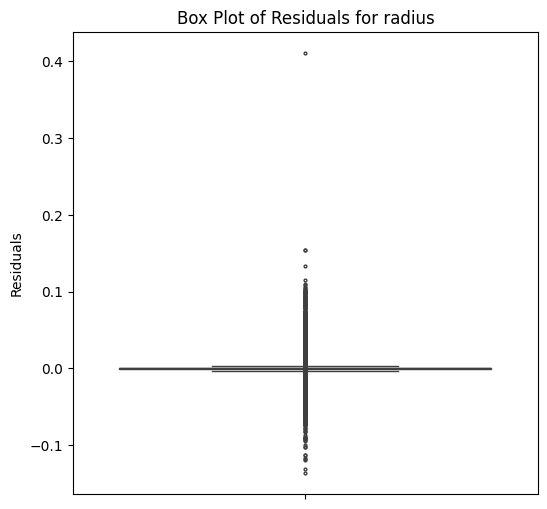

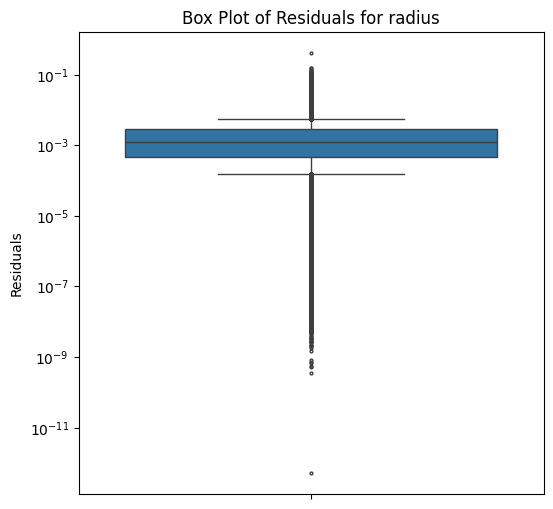

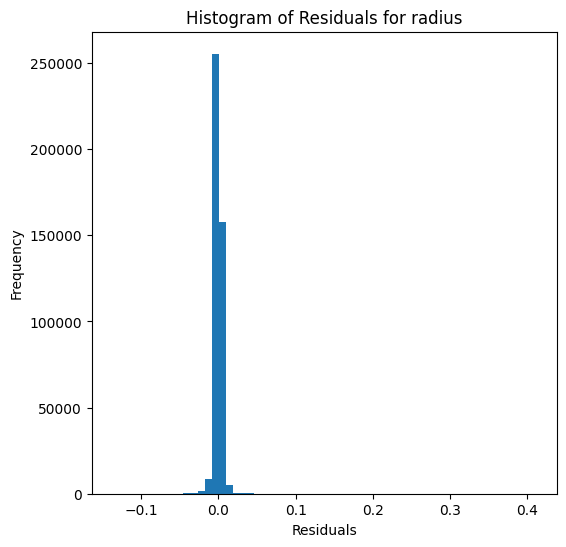

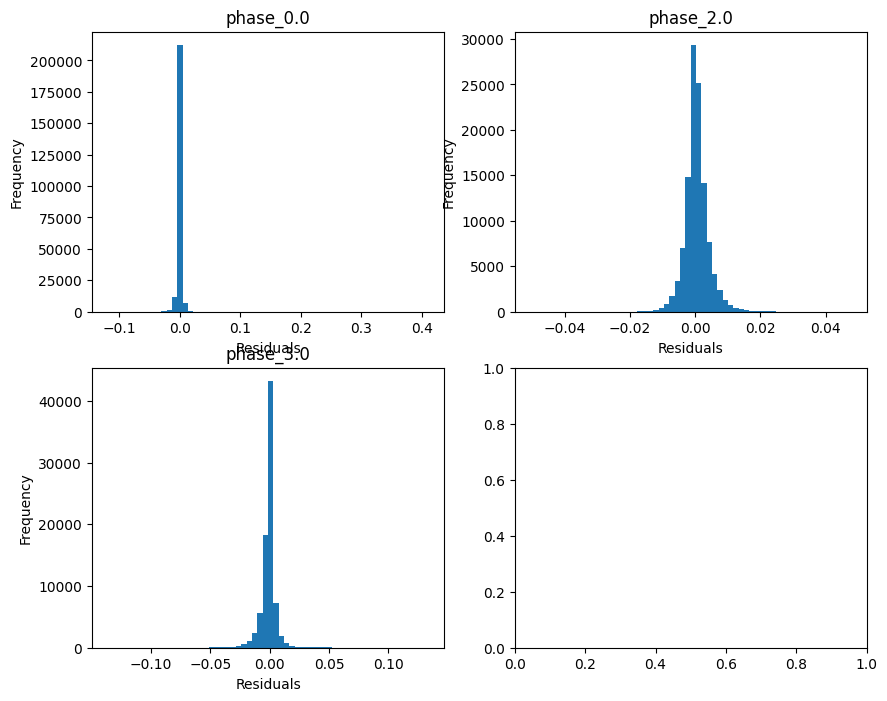

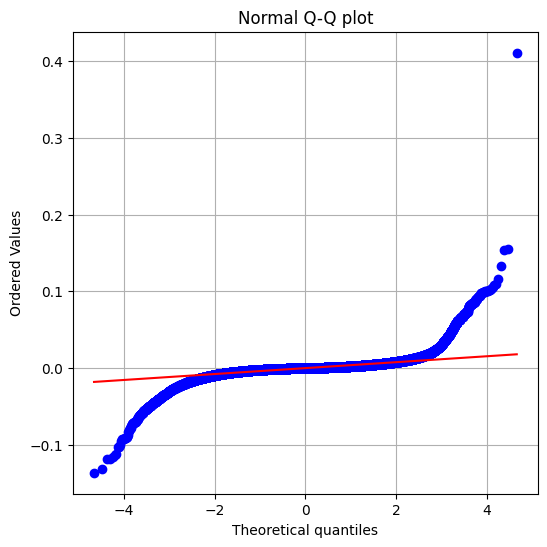

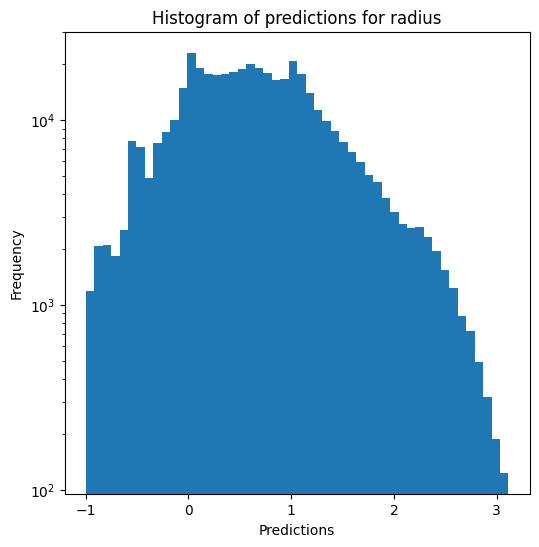

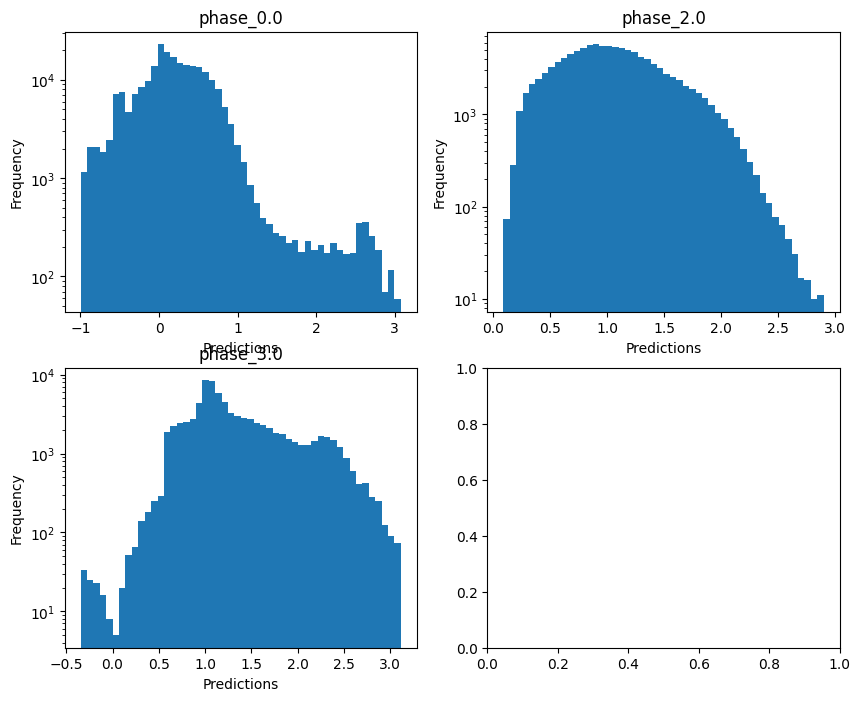

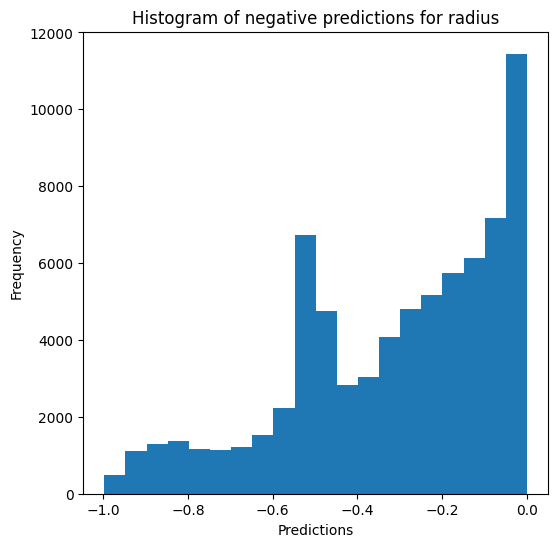

Saving predictions and results...


In [20]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### XGBoost

In [21]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 29.997679694990666
  RVE :  0.997607113775301
  RMSE :  0.3060783650852377
  MAE :  0.1412651791060079
  MedAE :  0.05449525160916824
  CORR :  0.9988031364064863
  MAX_ER :  5.6561268052070055
  Percentiles : 
    75th percentile :  0.1430703782549923
    90th percentile :  0.3374560333576037
    95th percentile :  0.5636551637536306
    99th percentile :  1.365161711346944

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 29.67887151062485
  RVE :  0.9996770428541898
  RMSE :  0.10897754026092366
  MAE :  0.06215164898174223
  MedAE :  0.03474880196437091
  CORR :  0.9998391744806859
  MAX_ER :  3.2774885227961335
  Percentiles : 
    75th percentile :  0.07638720565771528
    90th percentile :  0.14103713171830917
    95th 

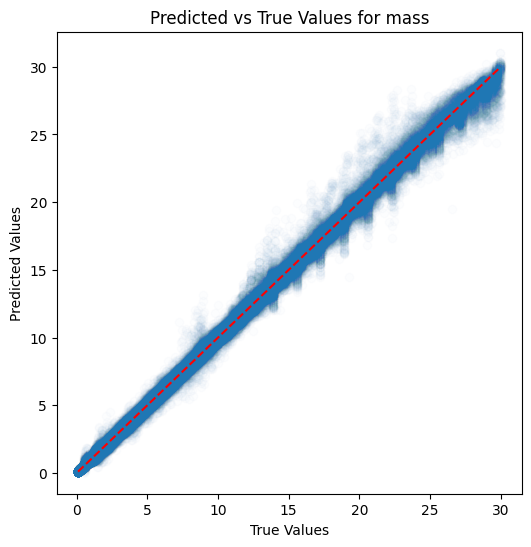

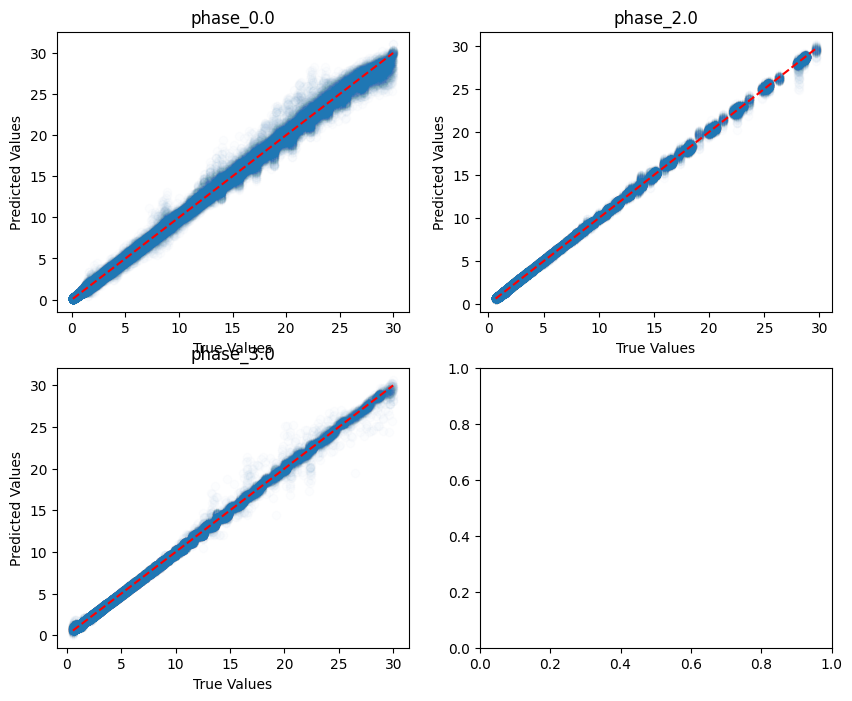

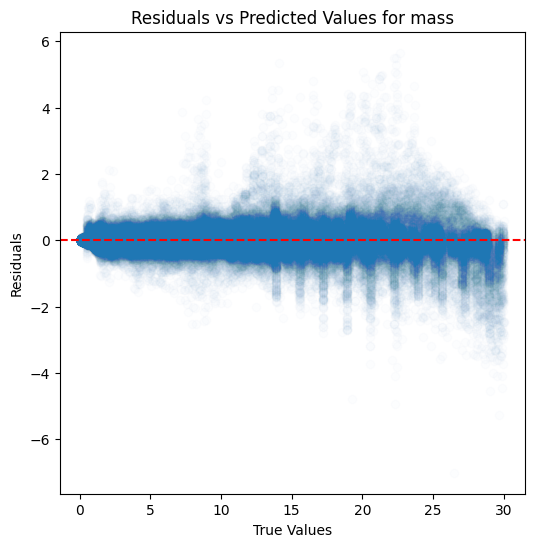

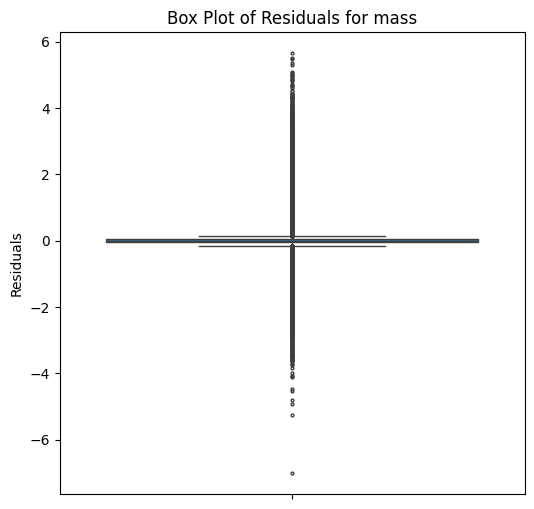

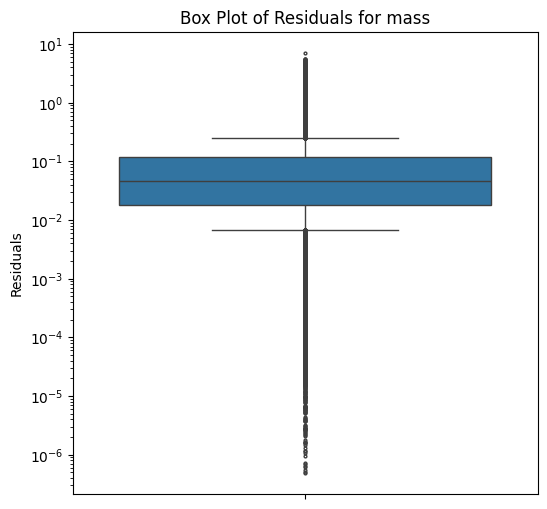

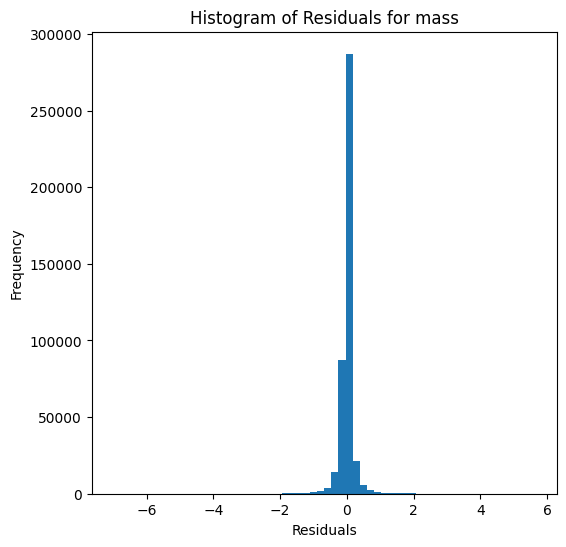

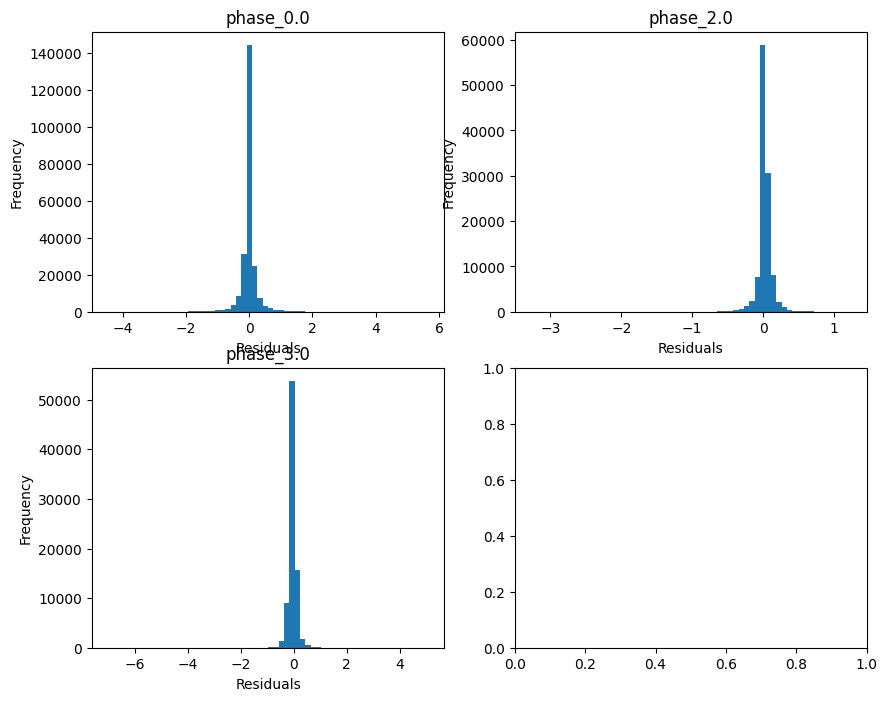

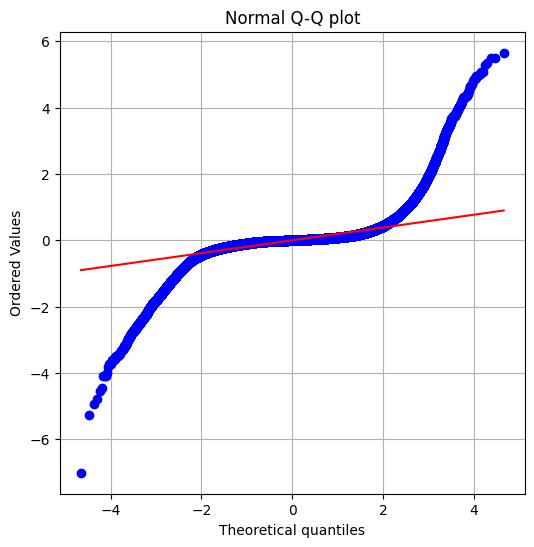

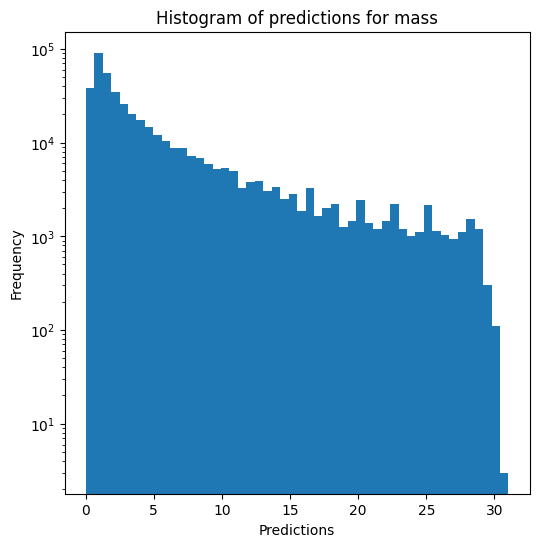

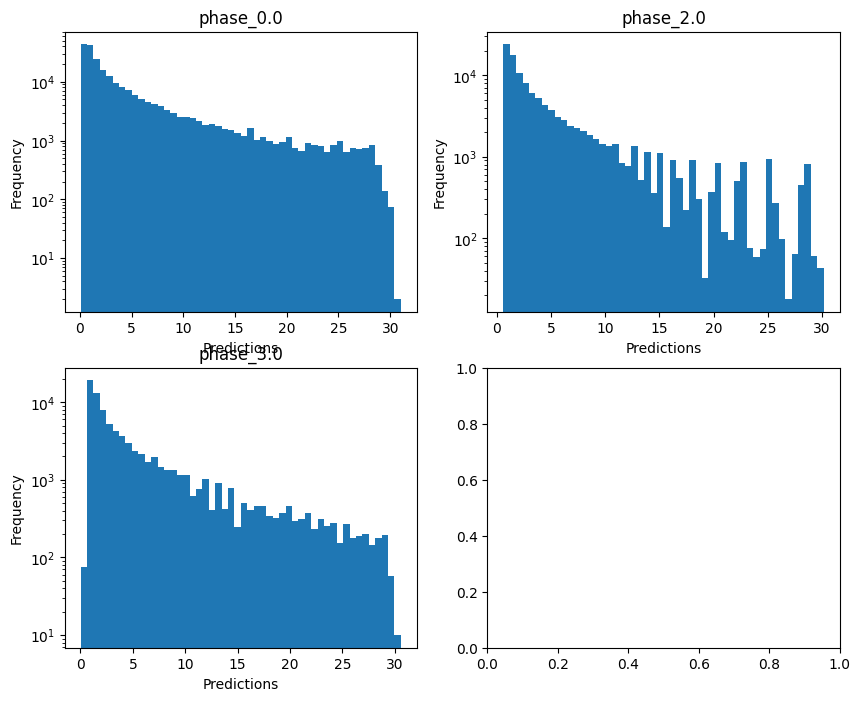


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9995381873053741
  RMSE :  0.010870919943919876
  MAE :  0.00823829193619723
  MedAE :  0.0063837713416286
  CORR :  0.9997690783741953
  MAX_ER :  0.09369711353624899
  Percentiles : 
    75th percentile :  0.011544502826474599
    90th percentile :  0.017875466395568855
    95th percentile :  0.022400500014365575
    99th percentile :  0.03183054685168159

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9992951333672936
  RMSE :  0.012090281228527778
  MAE :  0.009448358765782582
  MedAE :  0.007749238867062025
  CORR :  0.9996484433732039
  MAX_ER :  0.06542795161401127
  Percentiles : 
    75th percentile :  0.013422964793408876
    90th percentile :  0.019818976879999003
    95th percentile :  0.02417930201949784
    99th percentile :  0.03326591577673377

radius results for the 

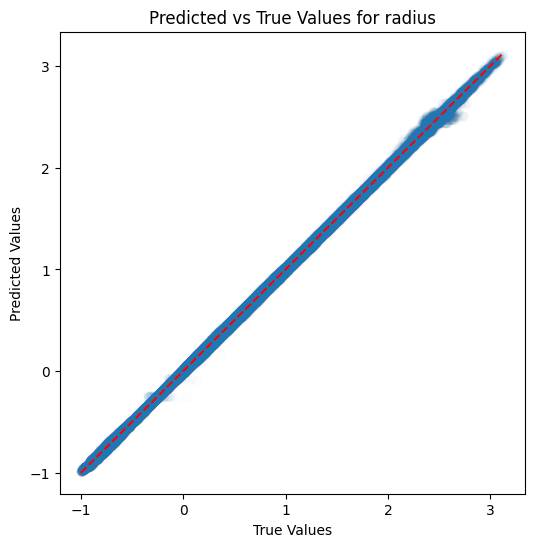

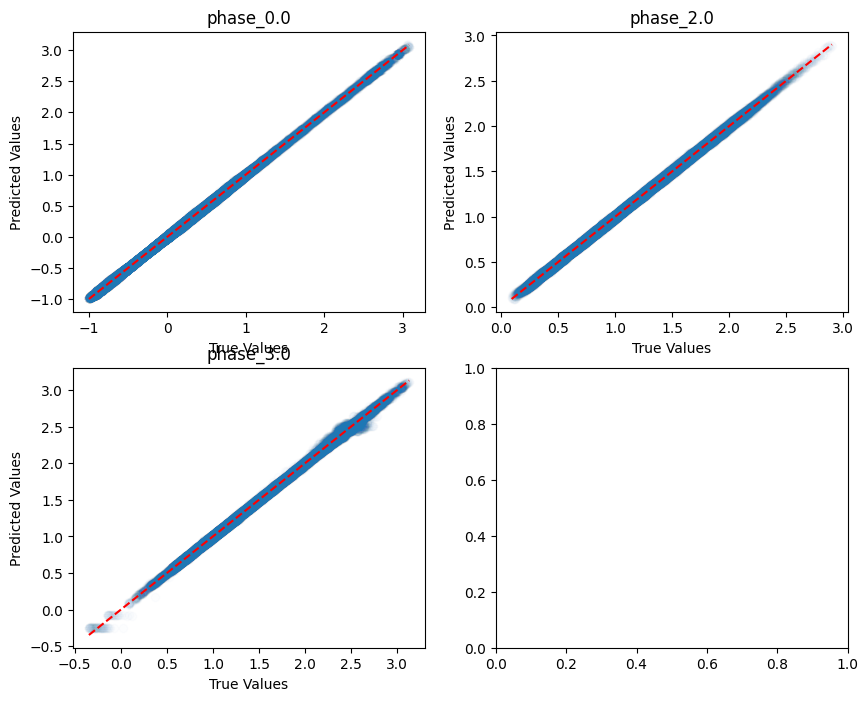

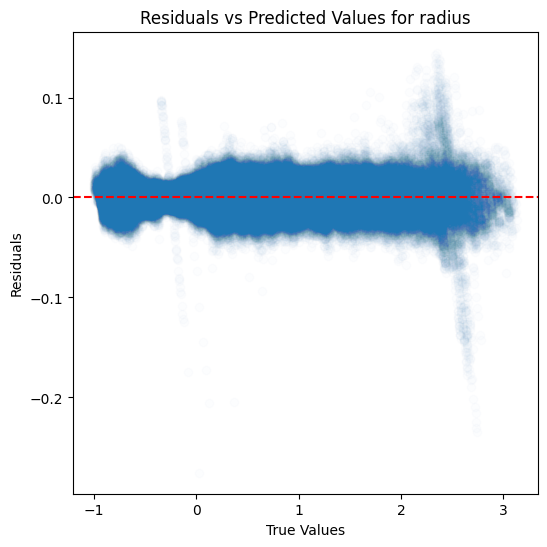

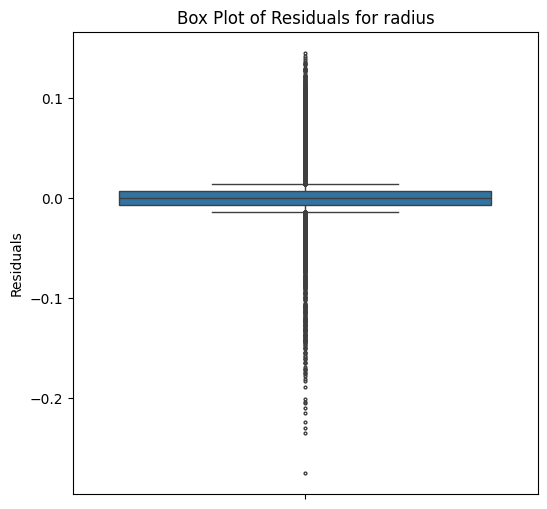

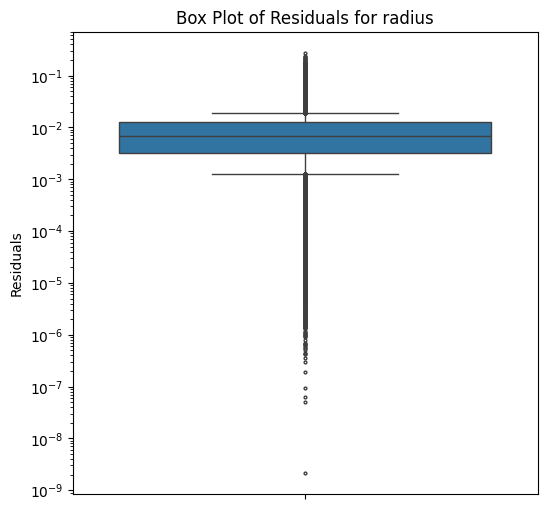

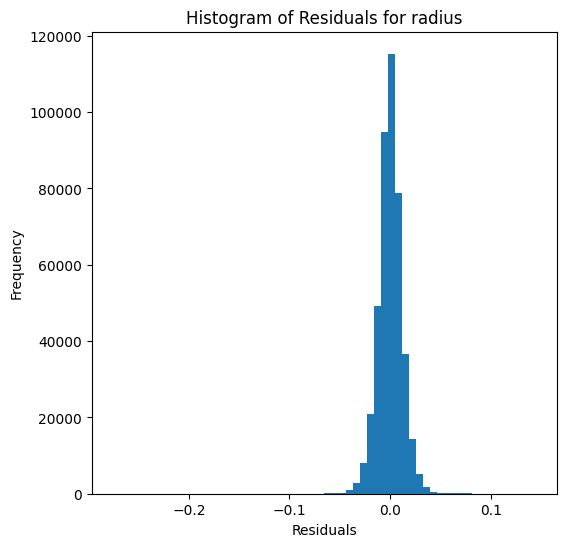

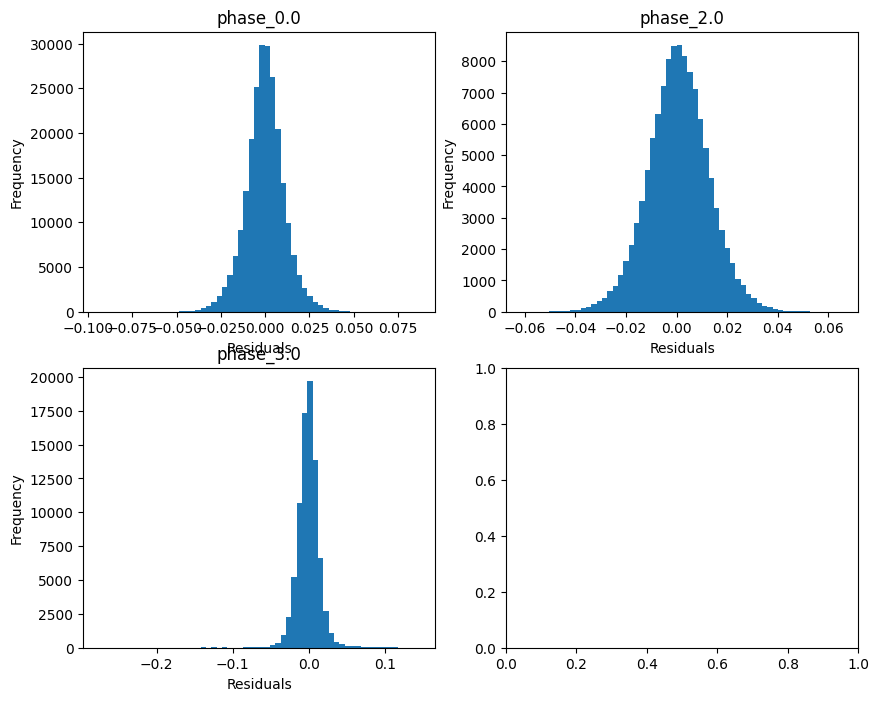

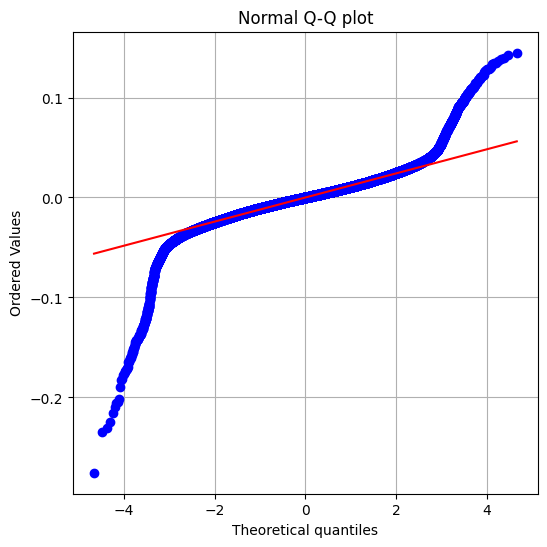

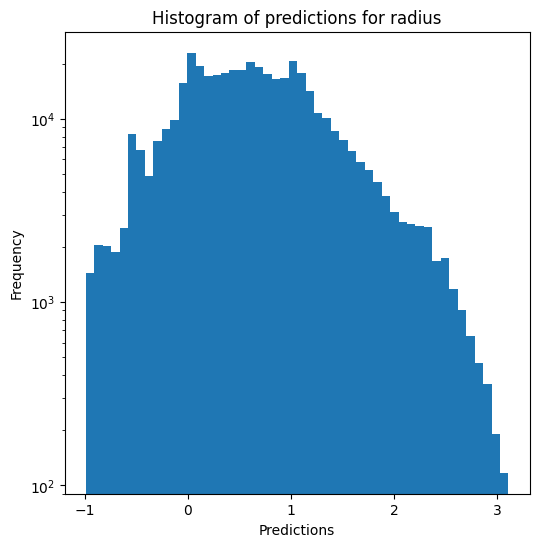

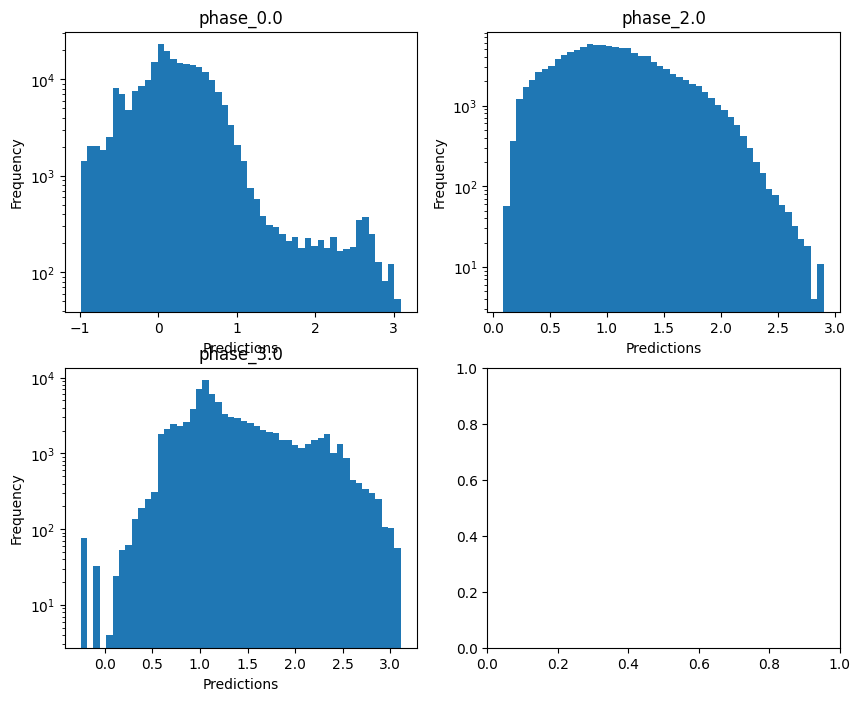

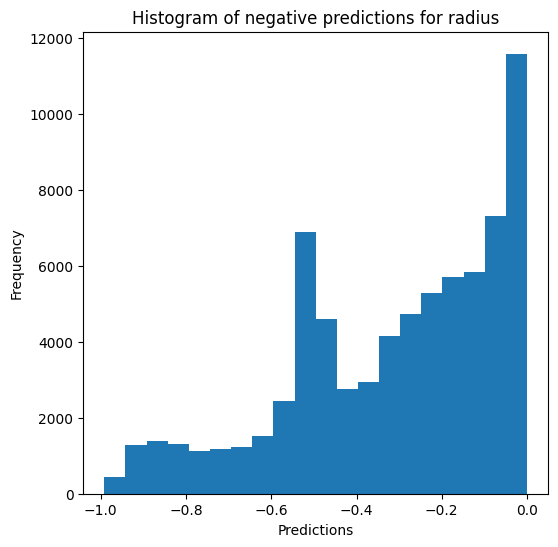

Saving predictions and results...


In [22]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### Multi-layer perceptron

In [23]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.10241936816006499
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.09674812402213716
3 

...

0.09027853254338607
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.12048545922415851
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.109195315841482

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 29.997679694990666
  RVE :  0.949307847125218
  RMSE :  1.4510970341734637
  MAE :  0.5629690204528734
  MedAE :  0.14942522023152444
  CORR :  0.9748944519439862
  MAX_ER :  19.56445584916382
  Percentiles : 
    75th percentile :  0.40732877573693216
    90th percentile :  1.2780409772160746
    95th percentile :  2.6148038969032186
    99th percentile :  7.173751604607447

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 29.67887151062485
  RVE :  0.9841625316617302
  RMSE :  0.7912360100476175
  MAE :  0.3391742338211382
  MedAE :  0.15809180966385972
  CORR :  0.992485884060122
  MAX_ER :  10.058072774174658
  Percentiles : 
    75th percentile :  0.29008623484007545
    90th percentile :  0.6675111666581873
    95th percentile :  1.2171771785317012
    99th percentile :  3.908416262369615

mass res

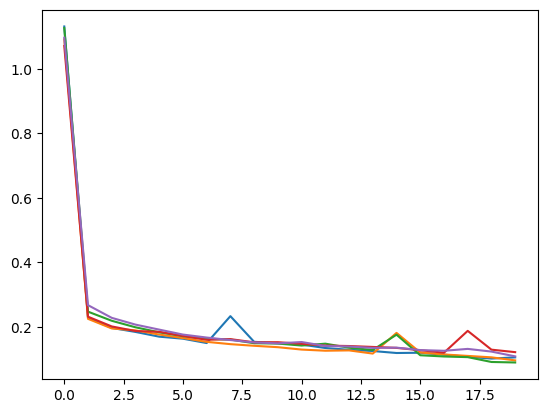

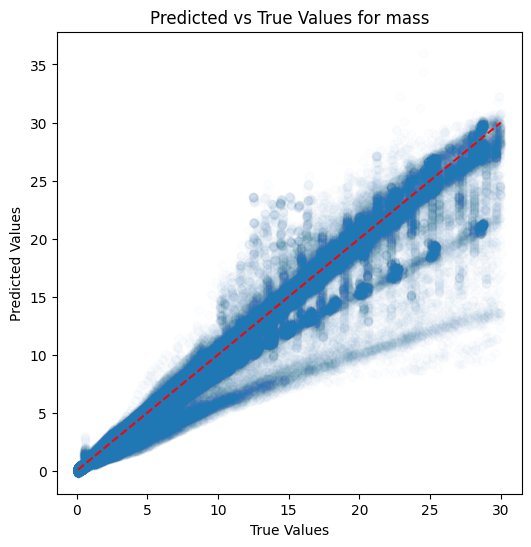

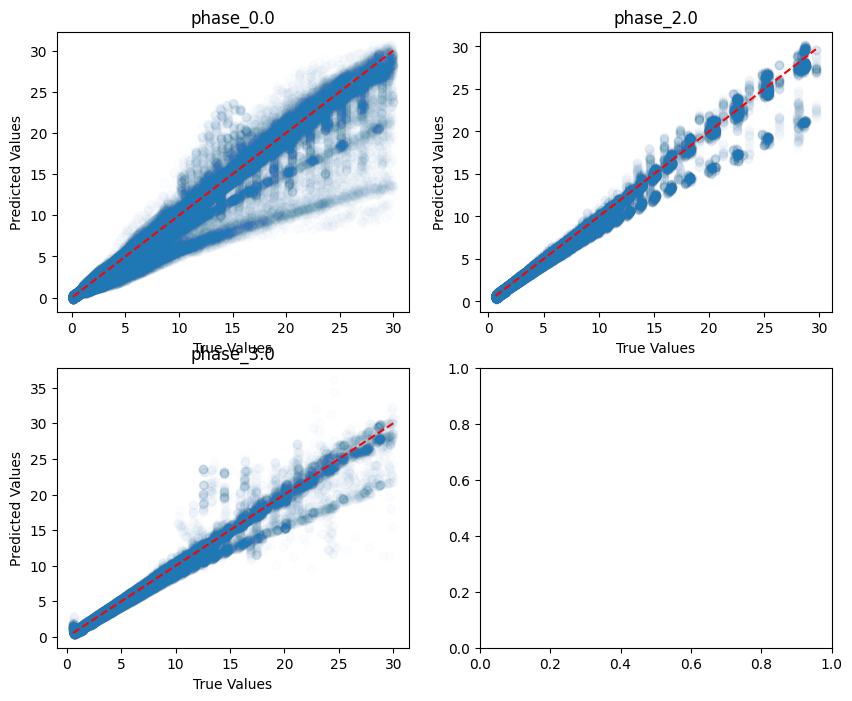

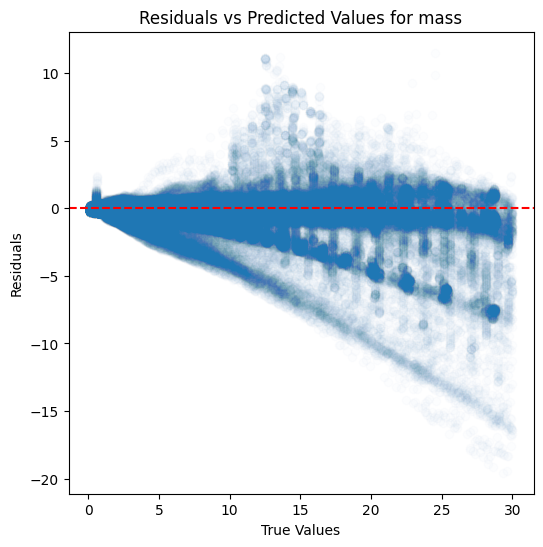

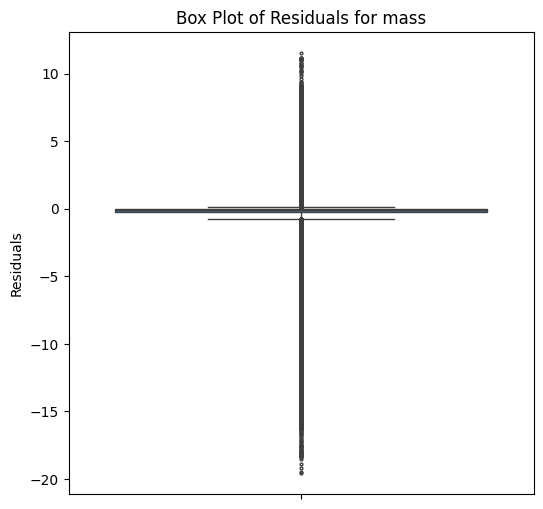

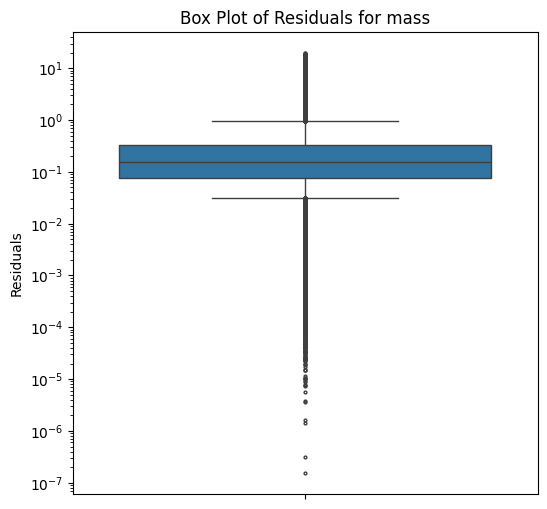

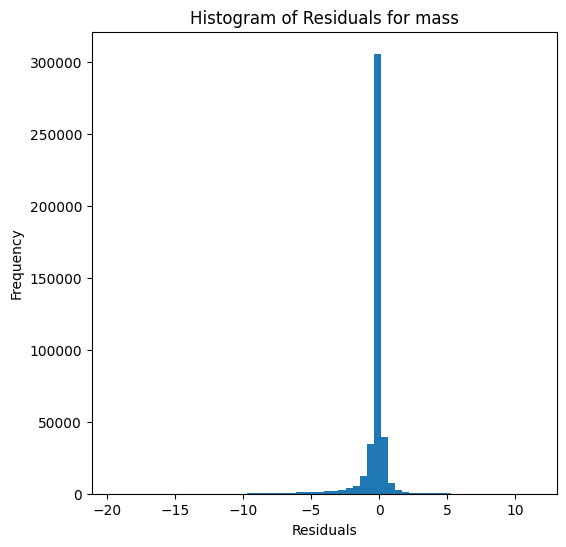

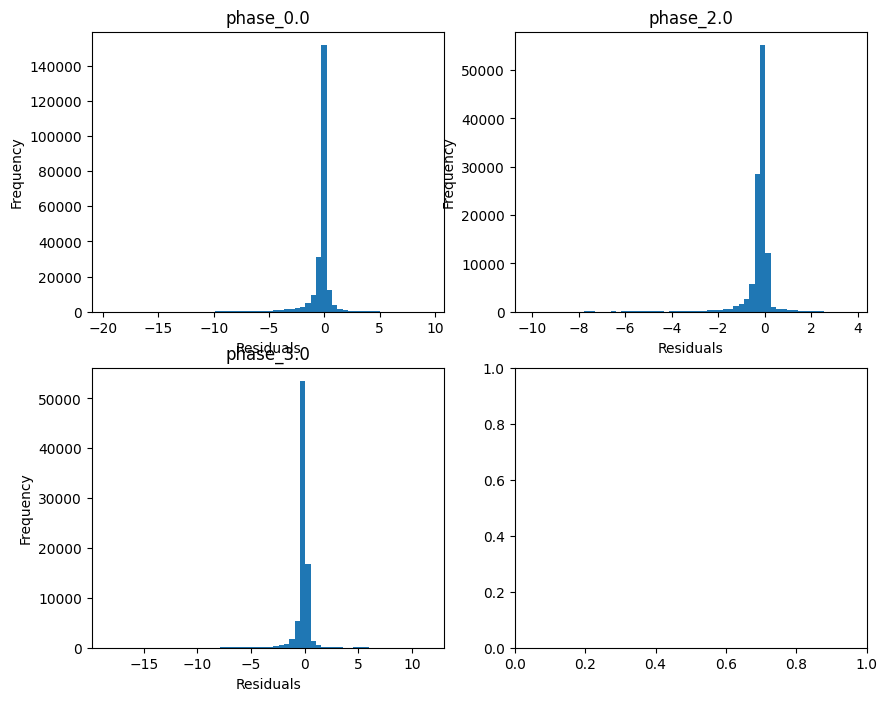

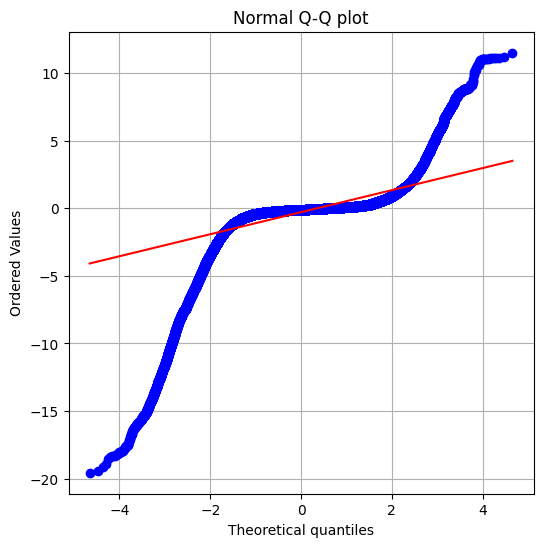

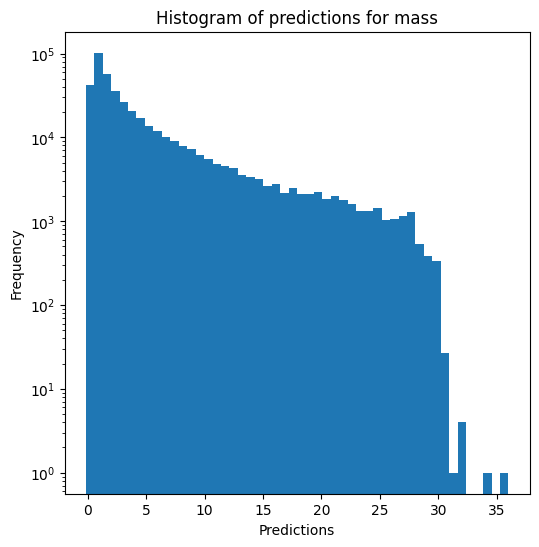

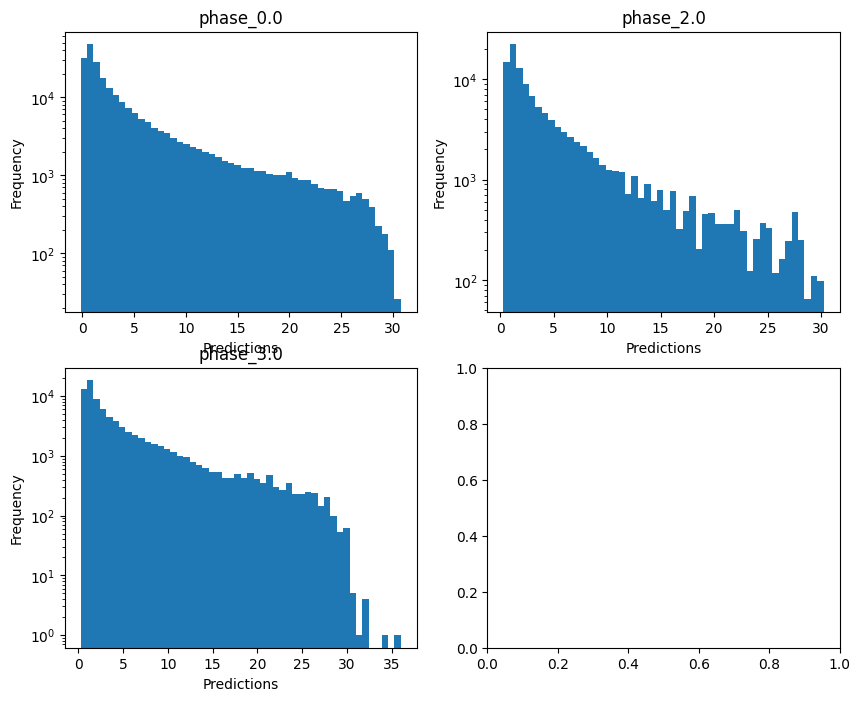

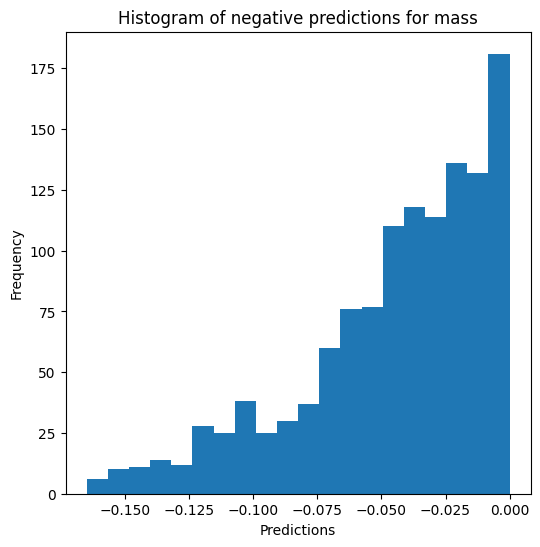


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9901288111552154
  RMSE :  0.06233597928907147
  MAE :  0.047467040640938304
  MedAE :  0.03565105045690402
  CORR :  0.995207168464403
  MAX_ER :  0.2713555222019235
  Percentiles : 
    75th percentile :  0.06817343579690563
    90th percentile :  0.10481998834400648
    95th percentile :  0.13018086230251888
    99th percentile :  0.1743451049269039

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9906433853956087
  RMSE :  0.060663254570256266
  MAE :  0.04804017567444183
  MedAE :  0.0383423117944135
  CORR :  0.9953134588767328
  MAX_ER :  0.24419735013812138
  Percentiles : 
    75th percentile :  0.0685308184506559
    90th percentile :  0.10584361742725588
    95th percentile :  0.12350920114588208
    99th percentile :  0.14969058000381316

radius results for the phase categ

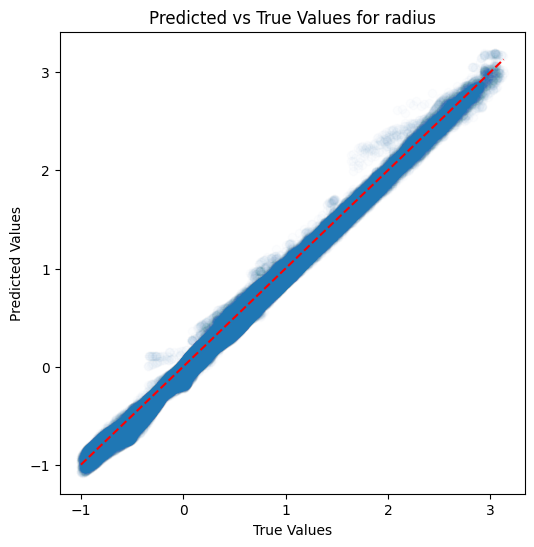

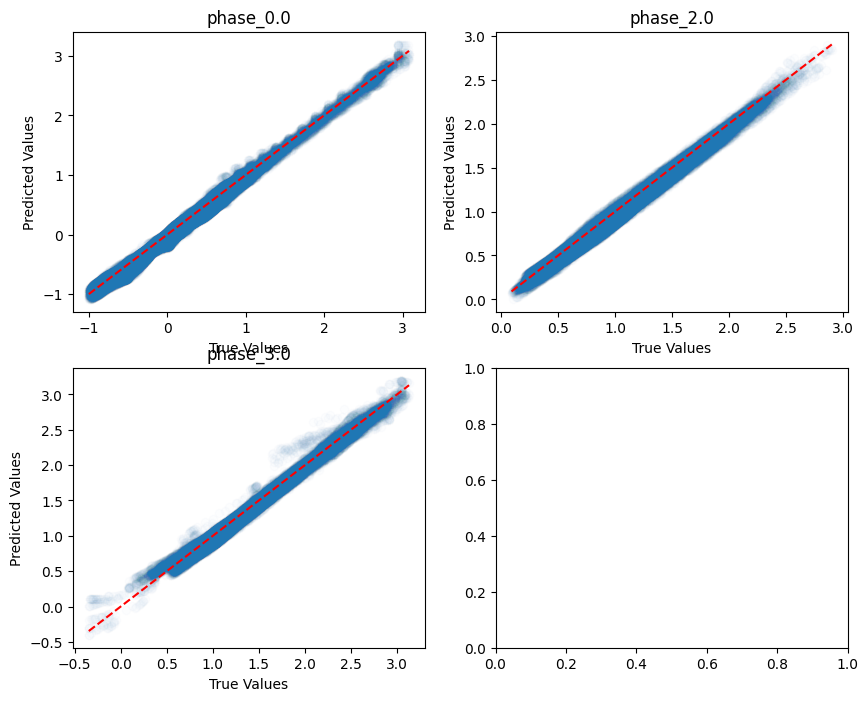

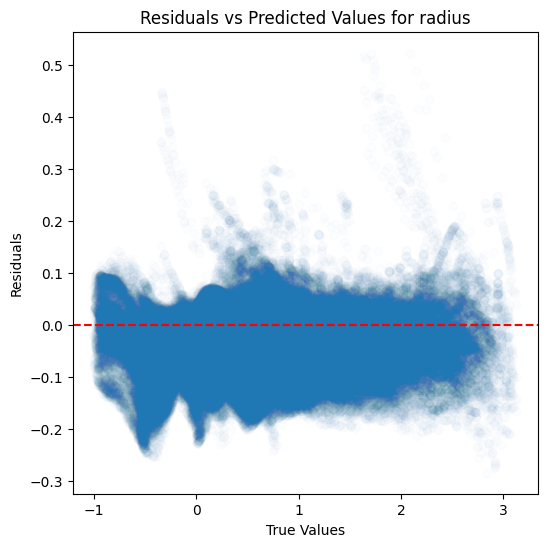

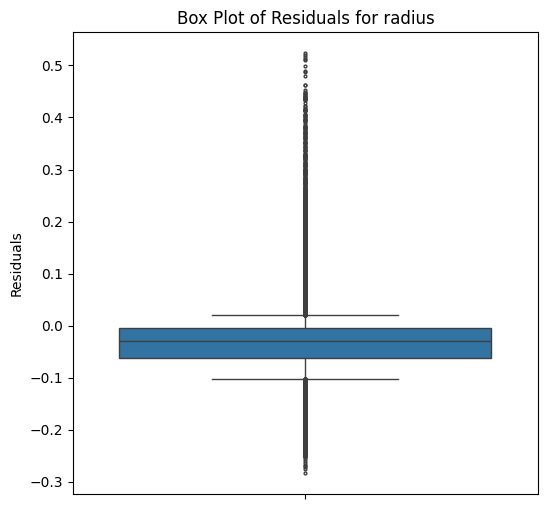

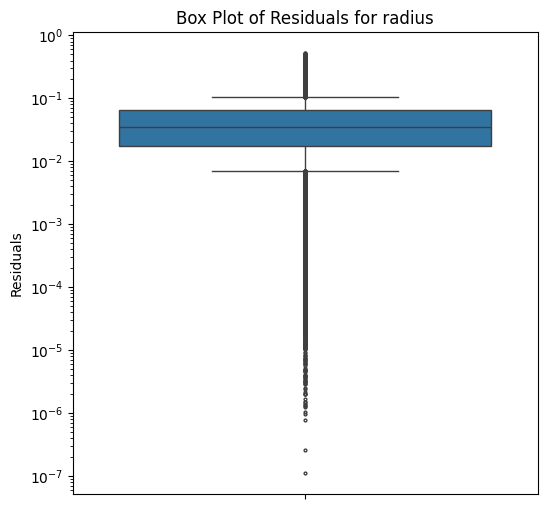

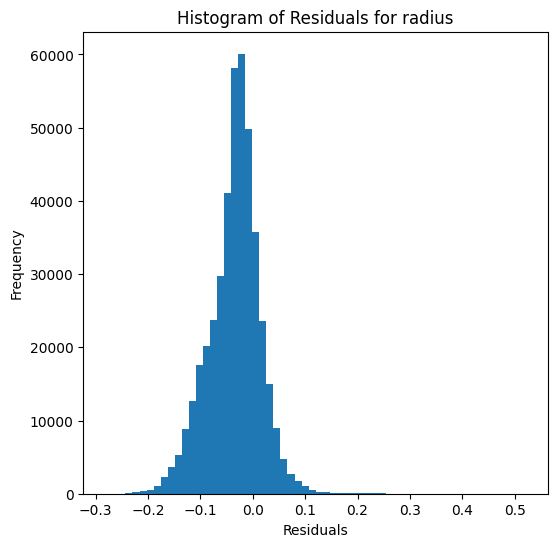

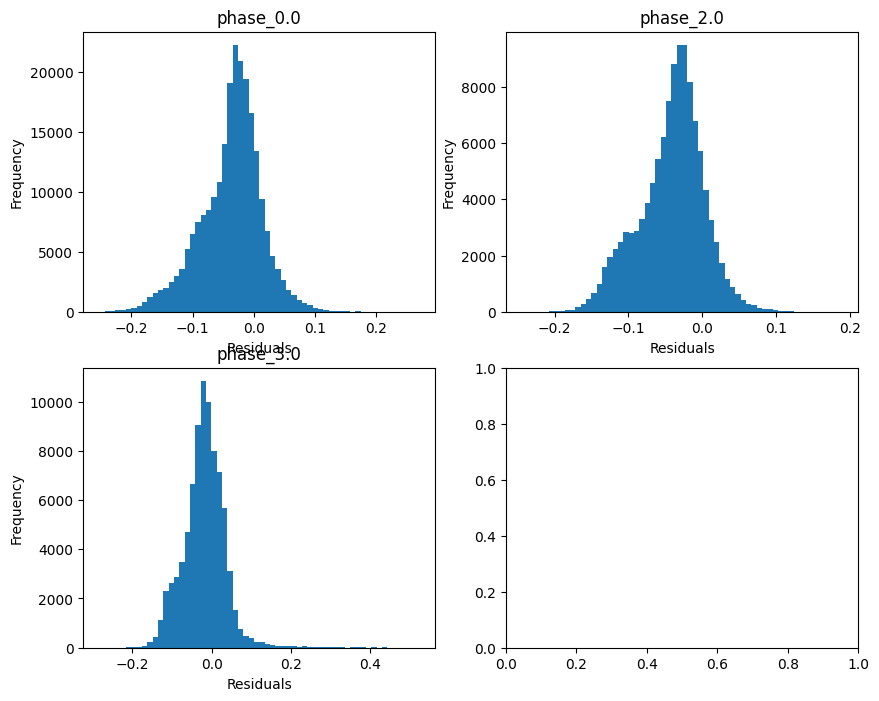

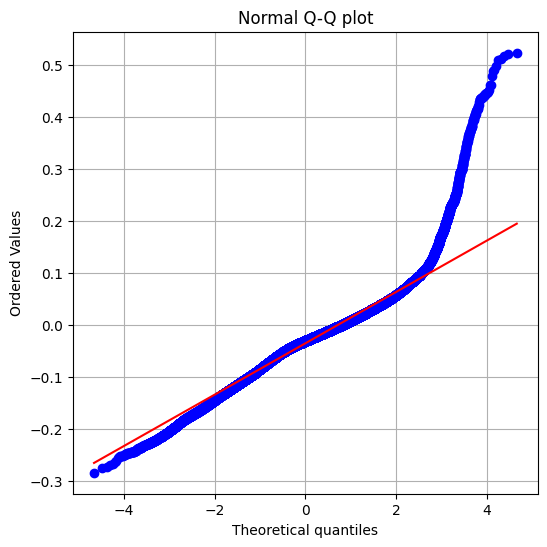

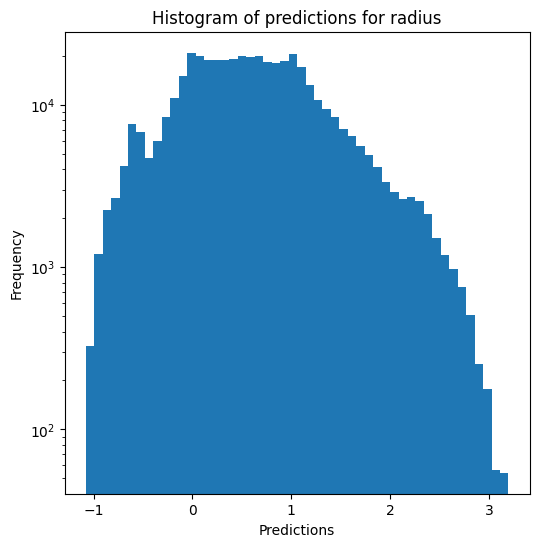

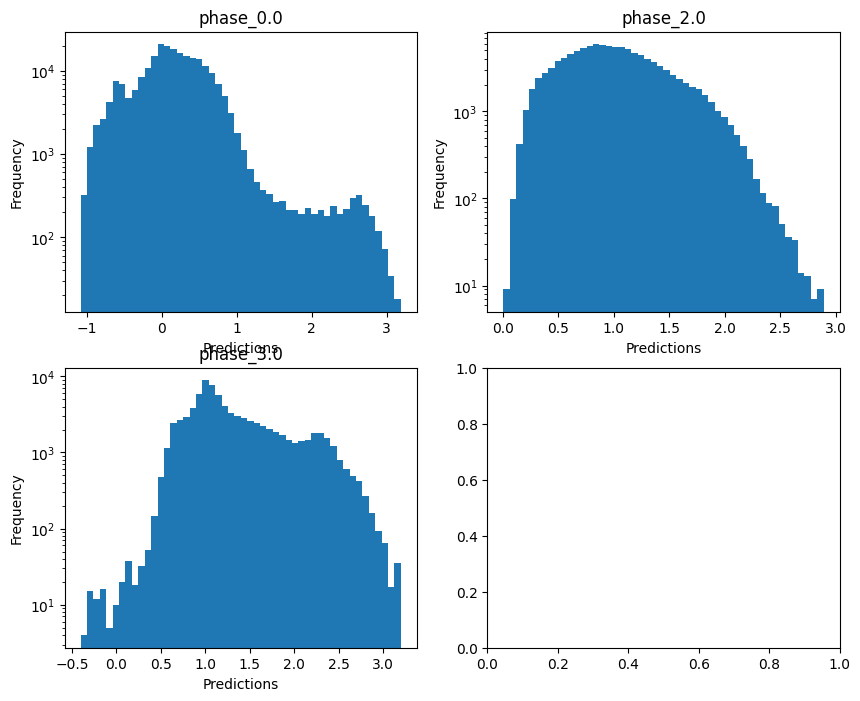

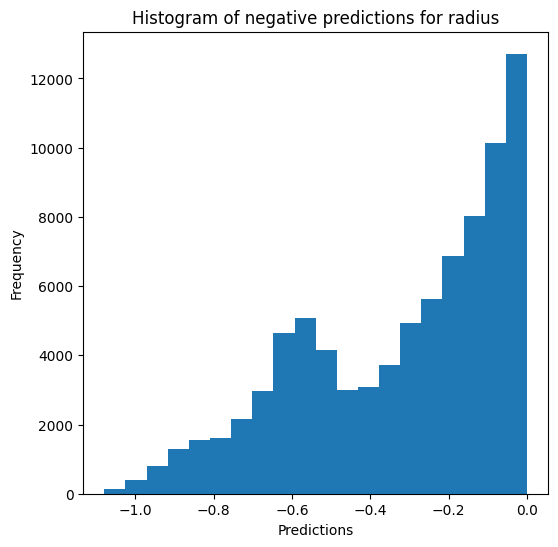

Saving predictions and results...


In [24]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, 
                                     hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)